# Analisis Distribusi dan Risiko Portofolio Pinjaman IBRD Berdasarkan Negara, Wilayah, dan Periode Waktu Menggunakan Data Warehouse dan OLAP

**Matakuliah :** Data Warehouse  
**Dosen Pengampu :** Hasanuddin Al-Habib, M.Si  
**Dataset :** IBRD Statement of Loans and Guarantees — Historical Data (World Bank)  
**Sumber :** https://financesone.worldbank.org/ibrd-statement-of-loans-and-guarantees-historical-data/DS00975


**Disusun Oleh:**

1. Tamaela Nurandyapasa  (24031554044)
2. Niha Nur Mayla Putri (24031554057)
3. Ilmin Nur Lailiyah  (24031554135)



## Daftar Isi
1. [Setup & Instalasi Library](#1-setup)
2. [Extract: Membaca Dataset](#2-extract)
3. [Periodic Simulation: Scheduler Berkala](#3-periodic)
4. [Transform: Pembersihan & Normalisasi Data](#4-transform)
5. [Load: PostgreSQL Cloud (Supabase)](#5-load)
6. [OLAP Optimization: Partisi, Materialized View, Index, Extensions](#6-olap)
7. [Atoti DataMart & Cube](#7-atoti)
8. [Atoti Widgets: Visualisasi (+ Fallback Plotly)](#8-widgets)
9. [Hasil Analisis & Insight](#9-analisis)
10. [Performance Benchmark: Index vs No-Index vs Materialized View](#10-benchmark)


## 1. Setup & Instalasi Library <a id='1-setup'></a>

In [ ]:
import subprocess, sys

packages = [
    "pandas", "numpy", "matplotlib", "seaborn",
    "sqlalchemy", "psycopg2-binary", "python-dotenv",
    "APScheduler", "aiofiles", "aiohttp", "nest_asyncio",
    "tqdm", "tabulate", "atoti",
]

for pkg in packages:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], check=False)
print("Semua package terinstal!")


Semua package terinstal!


In [ ]:
# IMPORT LIBRARY
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import asyncio
import aiofiles
import json
import time
import logging
import warnings
import nest_asyncio
from datetime import datetime
from pathlib import Path
from io import StringIO
from tqdm import tqdm
from tabulate import tabulate
from sqlalchemy import create_engine, text
from apscheduler.schedulers.background import BackgroundScheduler

nest_asyncio.apply()
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[
        logging.FileHandler("dw_pipeline.log"),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger("DW_IBRD")

print("Semua library berhasil diimport!")
# print(f"Tanggal eksekusi : {datetime.now().strftime('%d %B %Y — %H:%M:%S')}")

Semua library berhasil diimport!


In [ ]:
from IPython.display import display

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")

In [ ]:
# DATABASE KONFIGURASI
DB_CONFIG = {
    "host": "aws-1-ap-northeast-1.pooler.supabase.com",
    "port": "6543",
    "database": "postgres",
    "user": "postgres.skesyknkacauvkcoenom",
    "password": "MinMayMel4457135UNESA"
}

In [ ]:
# DB_CONFIG = {
#     "host": os.getenv("DB_HOST"),
#     "port": os.getenv("DB_PORT"),
#     "database": os.getenv("DB_NAME"),
#     "user": os.getenv("DB_USER"),
#     "password": os.getenv("DB_PASSWORD")
# }

In [ ]:
# DATABASE CONNECTION STRING
DATABASE_URL = (
    f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
    f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"
)
print("Database URL berhasil dibuat")

Database URL berhasil dibuat


In [ ]:
# Direktori data
DATA_DIR   = Path("data")
RAW_DIR    = DATA_DIR / "raw"
PROC_DIR   = DATA_DIR / "processed"
PERIOD_DIR = DATA_DIR / "periodic"

In [ ]:
# CREATE DIRECTORIES
for d in [RAW_DIR, PROC_DIR, PERIOD_DIR]:
    d.mkdir(parents=True, exist_ok=True)
print("Struktur folder berhasil dibuat")

Struktur folder berhasil dibuat


In [ ]:
# RAW DATASET LOCATION
from pathlib import Path
RAW_FILE = Path(r"C:\Users\ILMIN\Documents\Latihan coding\.vscode\uas dw\dataset.csv")

print("Dataset ditemukan")
print(f"Dataset : {RAW_FILE}")

Dataset ditemukan
Dataset : C:\Users\ILMIN\Documents\Latihan coding\.vscode\uas dw\dataset.csv


## 2. Extract: Membaca Dataset IBRD <a id='2-extract'></a>

Dataset diunduh dari World Bank Finance Portal:  
**https://financesone.worldbank.org/ibrd-statement-of-loans-and-guarantees-historical-data/DS00975**


In [ ]:
# ETL - EXTRACT PHASE
# CLASS: IBRD DATA EXTRACTOR
class IBRDExtractor:
    """
    Kelas untuk mengekstraksi data dari file CSV IBRD.
    Mendukung pembacaan penuh maupun incremental per periode.
    """
    def __init__(self, filepath: Path):
        self.filepath = filepath
        self.logger   = logging.getLogger("DW_IBRD.Extractor")

    def extract(self) -> pd.DataFrame:
        self.logger.info(f"Membaca dataset dari: {self.filepath}")
        start = time.time()

        if not self.filepath.exists():
            raise FileNotFoundError(
                f"\n File tidak ditemukan: {self.filepath}\n"
            )

        for enc in ["utf-8", "latin-1", "cp1252"]:
            try:
                df = pd.read_csv(self.filepath, encoding=enc, low_memory=False, thousands=",")
                break
            except UnicodeDecodeError:
                continue

        elapsed = time.time() - start
        self.logger.info(
            f"Berhasil membaca {len(df):,} baris × {len(df.columns)} kolom "
            f"dalam {elapsed:.2f} detik"
        )
        return df
# DATA PROFILING & SCHEMA INSPECTION
    def get_schema(self, df: pd.DataFrame) -> None:
        print(" SCHEMA DATASET IBRD \n")
        schema = pd.DataFrame({
            "Kolom"        : df.columns,
            "Tipe Data"    : df.dtypes.values,
            "Non-Null"     : df.notnull().sum().values,
            "Null"         : df.isnull().sum().values,
            "Null %"       : (df.isnull().mean() * 100).round(2).values,
            "Contoh Nilai" : [
                str(df[col].dropna().iloc[0])[:40] if df[col].notnull().any() else "-"
                for col in df.columns
            ]
        })
        print(tabulate(schema, headers="keys", tablefmt="fancy_grid", showindex=False))
        print(f"\nTotal Baris   : {len(df):,}")
        print(f"Total Kolom   : {len(df.columns)}")
        print(f"Memory Usage  : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

In [ ]:
# EXECUTE EXTRACTION
extractor = IBRDExtractor(RAW_FILE)

df_raw = extractor.extract()

print("Dataset berhasil diekstraksi")
print(f"Jumlah baris : {len(df_raw):,}")
print(f"Jumlah kolom : {len(df_raw.columns)}")

2026-06-05 09:51:46,054 [INFO] Membaca dataset dari: C:\Users\ILMIN\Documents\Latihan coding\.vscode\uas dw\dataset.csv
2026-06-05 09:52:02,984 [INFO] Berhasil membaca 1,537,969 baris × 33 kolom dalam 16.93 detik


Dataset berhasil diekstraksi
Jumlah baris : 1,537,969
Jumlah kolom : 33


In [ ]:
# DATASET PROFILING
extractor.get_schema(df_raw)

 SCHEMA DATASET IBRD 

╒══════════════════════════════════╤═════════════╤════════════╤═════════╤══════════╤═════════════════════════╕
│ Kolom                            │ Tipe Data   │   Non-Null │    Null │   Null % │ Contoh Nilai            │
╞══════════════════════════════════╪═════════════╪════════════╪═════════╪══════════╪═════════════════════════╡
│ End of Period                    │ object      │    1537969 │       0 │     0    │ 04/30/2024              │
├──────────────────────────────────┼─────────────┼────────────┼─────────┼──────────┼─────────────────────────┤
│ Loan Number                      │ object      │    1537969 │       0 │     0    │ IBRD00010               │
├──────────────────────────────────┼─────────────┼────────────┼─────────┼──────────┼─────────────────────────┤
│ Region                           │ object      │    1537969 │       0 │     0    │ EUROPE AND CENTRAL ASIA │
├──────────────────────────────────┼─────────────┼────────────┼─────────┼──────────┼─────

In [ ]:
# SAMPLE DATA PREVIEW
print("5 Baris Pertama:")
display(df_raw.head())

5 Baris Pertama:


,End of Period,Loan Number,Region,Country / Economy Code,Country / Economy,Borrower,Guarantor Country / Economy Code,Guarantor,Loan Type,Loan Status,Interest Rate,Currency of Commitment,Project ID,Project Name,Original Principal Amount (US$),Cancelled Amount (US$),Undisbursed Amount (US$),Disbursed Amount (US$),Repaid to IBRD (US$),Due to IBRD (US$),Exchange Adjustment (US$),Borrower's Obligation (US$),Sold 3rd Party (US$),Repaid 3rd Party (US$),Due 3rd Party (US$),Loans Held (US$),First Repayment Date,Last Repayment Date,Agreement Signing Date,Board Approval Date,Effective Date (Most Recent),Closed Date (Most Recent),Last Disbursement Date
0,04/30/2024,IBRD00010,EUROPE AND CENTRAL ASIA,FR,France,CREDIT NATIONAL,FR,France,NPL,Fully Repaid,4.25,NaN,P037383,RECONSTRUCTION,"250,000,000.00",0.00,0.00,"250,000,000.00","38,000.00",0.00,0.00,0.00,"249,962,000.00","249,962,000.00",0,0.00,11/01/1952,05/01/1977,05/09/1947,05/09/1947,06/09/1947,12/31/1947,NaN
1,06/30/2015,IBRD00010,EUROPE AND CENTRAL ASIA,FR,France,CREDIT NATIONAL,FR,France,NON POOL,Repaid,4.25,NaN,P037383,RECONSTRUCTION,"250,000,000.00",0.00,0.00,"250,000,000.00","38,000.00",0.00,0.00,0.00,"249,962,000.00","249,962,000.00",0,0.00,11/01/1952,05/01/1977,05/09/1947,05/09/1947,06/09/1947,12/31/1947,NaN
2,05/31/2015,IBRD00010,EUROPE AND CENTRAL ASIA,FR,France,CREDIT NATIONAL,NaN,France,NON POOL,Repaid,4.25,NaN,P037383,RECONSTRUCTION,"250,000,000.00",0.00,0.00,"250,000,000.00","38,000.00",0.00,0.00,0.00,"249,962,000.00","249,962,000.00",0,0.00,11/01/1952,05/01/1977,05/09/1947,05/09/1947,06/09/1947,12/31/1947,NaN
3,04/30/2015,IBRD00010,EUROPE AND CENTRAL ASIA,FR,France,CREDIT NATIONAL,FR,France,NON POOL,Repaid,4.00,NaN,P037383,RECONSTRUCTION,"250,000,000.00",0.00,0.00,"250,000,000.00","38,000.00",0.00,0.00,0.00,"249,962,000.00","249,962,000.00",0,0.00,11/01/1952,05/01/1977,05/09/1947,05/09/1947,06/09/1947,12/31/1947,NaN
4,03/31/2015,IBRD00010,EUROPE AND CENTRAL ASIA,FR,France,CREDIT NATIONAL,FR,France,NON POOL,Repaid,4.25,NaN,P037383,RECONSTRUCTION,"250,000,000.00",0.00,0.00,"250,000,000.00","38,000.00",0.00,0.00,0.00,"249,962,000.00","249,962,000.00",0,0.00,11/01/1952,05/01/1977,05/09/1947,05/09/1947,06/09/1947,12/31/1947,NaN


In [ ]:
# DESCRIPTIVE STATISTICS
print("Statistik Deskriptif (Numerik):")
display(df_raw.describe())

Statistik Deskriptif (Numerik):


,Interest Rate,Currency of Commitment,Original Principal Amount (US$),Cancelled Amount (US$),Undisbursed Amount (US$),Disbursed Amount (US$),Repaid to IBRD (US$),Due to IBRD (US$),Exchange Adjustment (US$),Borrower's Obligation (US$),Sold 3rd Party (US$),Repaid 3rd Party (US$),Due 3rd Party (US$),Loans Held (US$)
count,"1,504,846.00",0.00,"1,537,969.00","1,537,969.00","1,537,969.00","1,537,969.00","1,537,969.00","1,537,969.00","1,537,969.00","1,537,969.00","1,537,969.00","1,537,969.00","1,537,969.00","1,537,969.00"
mean,4.35,NaN,"86,422,695.83","10,568,940.24","8,408,775.72","67,415,431.96","43,431,146.07","23,647,005.20","-413,179.47","23,233,825.73","437,395.32","437,395.32",0.00,"32,055,780.92"
std,3.39,NaN,"158,286,766.75","47,377,993.41","52,276,814.90","139,451,484.39","93,363,615.87","102,450,947.40","11,861,936.65","98,919,500.14","3,838,081.18","3,838,081.18",0.00,"119,190,951.25"
min,0.00,NaN,0.00,0.00,"-122,660,000.00",0.00,0.00,"-148,309,024.60","-1,100,785,334.00",-0.33,0.00,0.00,0.00,"-148,309,024.60"
25%,0.00,NaN,"12,305,000.00",0.00,0.00,"6,800,000.00","2,896,431.08",0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,5.21,NaN,"34,014,624.66",404.50,0.00,"23,900,000.00","15,279,003.19",0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,7.25,NaN,"100,000,000.00","3,850,000.00",0.00,"70,000,000.00","45,697,739.25",0.00,0.00,0.00,0.00,0.00,0.00,0.00
max,28.25,NaN,"3,750,000,000.00","1,995,000,000.00","3,379,010,725.00","3,153,530,829.10","3,000,000,000.00","2,923,281,691.00","506,576,655.30","2,842,923,759.00","249,962,000.00","249,962,000.00",0.00,"3,750,000,000.00"


## 3. Periodic Simulation Ekstraksi Berkala (Asynchronous) <a id='3-periodic'></a>

Proses ekstraksi disimulasikan berlangsung secara berkala menggunakan:
- **APScheduler**: penjadwalan berkala (simulasi proses harian/kuartalan)
- **asyncio + aiofiles**: proses asynchronous (**Bonus +10**)


### PERIODIC DATA ACQUISITION SIMULATION

In [ ]:
def create_periodic_splits(df: pd.DataFrame) -> dict:
    """
    Membagi dataset menjadi file-file periodik per kuartal
    untuk mensimulasikan proses akuisisi data berkala.
    """
    logger.info("Membuat split data periodik per kuartal...")

    date_cols = [c for c in df.columns if any(
        kw in c.lower() for kw in ["date", "tanggal", "period", "year"]
    )]
    print(f"Kolom tanggal terdeteksi: {date_cols}")

    date_col = next(
        (c for c in date_cols if "approval" in c.lower() or "board" in c.lower()),
        date_cols[0] if date_cols else None
    )
# FALLBACK SPLITTING (INDEX-BASED)
    if date_col is None:
        chunk_size = len(df) // 8
        files = {}
        for i in range(8):
            chunk   = df.iloc[i*chunk_size:(i+1)*chunk_size].copy()
            quarter = f"Q{(i%4)+1}_{2023 + i//4}"
            fname   = PERIOD_DIR / f"ibrd_{quarter}.csv"
            chunk.to_csv(fname, index=False)
            files[quarter] = fname
            logger.info(f"  Dibuat: {fname.name} ({len(chunk):,} baris)")
        return files
# QUARTERLY SPLIT BASED ON DATE COLUMN
    df_dated = df.copy()
    df_dated[date_col]    = pd.to_datetime(df_dated[date_col], errors="coerce")
    df_dated              = df_dated.dropna(subset=[date_col])
    df_dated["_year"]     = df_dated[date_col].dt.year
    df_dated["_quarter"]  = df_dated[date_col].dt.quarter

    recent_years = sorted(df_dated["_year"].unique())[-2:]
    df_recent    = df_dated[df_dated["_year"].isin(recent_years)].copy()

    print(f"\nKolom tanggal  : '{date_col}'")
    print(f"Rentang tahun  : {recent_years}")
    print(f"Total baris    : {len(df_recent):,}")
# FALLBACK SPLITTING (INDEX-BASED)
    files = {}
    for year in recent_years:
        for q in range(1, 5):
            mask  = (df_recent["_year"] == year) & (df_recent["_quarter"] == q)
            chunk = df_recent[mask].drop(columns=["_year", "_quarter"])
            if len(chunk) == 0:
                continue
            key   = f"Q{q}_{year}"
            fname = PERIOD_DIR / f"ibrd_{key}.csv"
            chunk.to_csv(fname, index=False)
            files[key] = fname
            logger.info(f"  Dibuat: {fname.name} ({len(chunk):,} baris)")

    print(f"\n Total {len(files)} file periodik dibuat di {PERIOD_DIR}/")
    return files


In [ ]:
# EXECUTE PERIODIC EXTRACTION
periodic_files = create_periodic_splits(df_raw)
print("\n Simulasi ekstraksi periodik berhasil")

2026-06-05 09:52:29,871 [INFO] Membuat split data periodik per kuartal...


Kolom tanggal terdeteksi: ['End of Period', 'First Repayment Date', 'Last Repayment Date', 'Agreement Signing Date', 'Board Approval Date', 'Effective Date (Most Recent)', 'Closed Date (Most Recent)', 'Last Disbursement Date']


2026-06-05 09:52:31,646 [INFO]   Dibuat: ibrd_Q1_2025.csv (594 baris)
2026-06-05 09:52:31,674 [INFO]   Dibuat: ibrd_Q2_2025.csv (481 baris)
2026-06-05 09:52:31,692 [INFO]   Dibuat: ibrd_Q3_2025.csv (258 baris)
2026-06-05 09:52:31,709 [INFO]   Dibuat: ibrd_Q4_2025.csv (231 baris)
2026-06-05 09:52:31,724 [INFO]   Dibuat: ibrd_Q1_2026.csv (122 baris)
2026-06-05 09:52:31,735 [INFO]   Dibuat: ibrd_Q2_2026.csv (8 baris)



Kolom tanggal  : 'Board Approval Date'
Rentang tahun  : [np.int32(2025), np.int32(2026)]
Total baris    : 1,694

 Total 6 file periodik dibuat di data\periodic/

 Simulasi ekstraksi periodik berhasil


In [ ]:
# PERIODIC FILE VERIFICATION
print("\n📁 File periodik yang dibuat:")
for key, fpath in periodic_files.items():
    size = fpath.stat().st_size / 1024
    print(f"   {key:10s} → {fpath.name:30s}  ({size:.1f} KB)")


📁 File periodik yang dibuat:
   Q1_2025    → ibrd_Q1_2025.csv                (166.8 KB)
   Q2_2025    → ibrd_Q2_2025.csv                (131.4 KB)
   Q3_2025    → ibrd_Q3_2025.csv                (69.3 KB)
   Q4_2025    → ibrd_Q4_2025.csv                (60.7 KB)
   Q1_2026    → ibrd_Q1_2026.csv                (31.6 KB)
   Q2_2026    → ibrd_Q2_2026.csv                (2.8 KB)


### ASYNCHRONOUS ETL PIPELINE

In [ ]:
# Menyimpan riwayat eksekusi ETL
etl_run_log = []
print("Async ETL Pipeline Initialized")

Async ETL Pipeline Initialized


In [ ]:
# ASYNC FILE READER menggunakan aiofiles
async def async_read_csv(filepath: Path) -> pd.DataFrame:
    logger.info(f"[ASYNC] Membaca: {filepath.name}")
    async with aiofiles.open(filepath, mode="r", encoding="utf-8") as f:
        content = await f.read()
    df = pd.read_csv(StringIO(content), low_memory=False)
    return df

In [ ]:
# ASYNC ETL FOR SINGLE PERIOD
async def async_etl_period(key: str, filepath: Path) -> dict:
    """Pipeline ETL asynchronous untuk satu periode."""
    start = time.time()
    logger.info(f"[ASYNC ETL] Memulai periode: {key}")
    try:
        df      = await async_read_csv(filepath)
        elapsed = time.time() - start
        summary = {
            "period"   : key,
            "file"     : filepath.name,
            "rows"     : len(df),
            "cols"     : len(df.columns),
            "elapsed_s": round(elapsed, 3),
            "status"   : "SUCCESS",
            "timestamp": datetime.now().isoformat(),
        }
        logger.info(f"[ASYNC ETL] ✅ {key}: {len(df):,} baris dalam {elapsed:.3f}s")
    except Exception as e:
        elapsed = time.time() - start
        summary = {
            "period"   : key,
            "file"     : filepath.name,
            "rows"     : 0,
            "cols"     : 0,
            "elapsed_s": round(elapsed, 3),
            "status"   : f"ERROR: {e}",
            "timestamp": datetime.now().isoformat(),
        }
        logger.error(f"[ASYNC ETL] ❌ {key}: {e}")
    etl_run_log.append(summary)
    return summary

In [ ]:
# ASYNC ETL ORCHESTRATOR
async def run_async_etl_all(files: dict) -> list:
    logger.info(f"[ASYNC ETL] Menjalankan {len(files)} periode secara paralel...")
    start_all = time.time()
    tasks     = [async_etl_period(k, v) for k, v in files.items()]
    results   = await asyncio.gather(*tasks)
    total_elapsed = time.time() - start_all
    sequential_est = sum(r["elapsed_s"] for r in results)
    logger.info(
        f"[ASYNC ETL]  Selesai dalam {total_elapsed:.3f}s "
        f"(vs sequential ~{sequential_est:.3f}s)"
    )
    return list(results)

In [ ]:
# EXECUTE ASYNC ETL PIPELINE
print("Menjalankan Async ETL Pipeline... \n")
results = asyncio.run(run_async_etl_all(periodic_files))

print(
    f"\n Total periode diproses : "
    f"{len(results)}"
)

2026-06-05 09:52:32,101 [INFO] [ASYNC ETL] Menjalankan 6 periode secara paralel...
2026-06-05 09:52:32,106 [INFO] [ASYNC ETL] Memulai periode: Q1_2025
2026-06-05 09:52:32,108 [INFO] [ASYNC] Membaca: ibrd_Q1_2025.csv
2026-06-05 09:52:32,113 [INFO] [ASYNC ETL] Memulai periode: Q2_2025
2026-06-05 09:52:32,117 [INFO] [ASYNC] Membaca: ibrd_Q2_2025.csv
2026-06-05 09:52:32,120 [INFO] [ASYNC ETL] Memulai periode: Q3_2025


Menjalankan Async ETL Pipeline... 



2026-06-05 09:52:32,124 [INFO] [ASYNC] Membaca: ibrd_Q3_2025.csv
2026-06-05 09:52:32,126 [INFO] [ASYNC ETL] Memulai periode: Q4_2025
2026-06-05 09:52:32,129 [INFO] [ASYNC] Membaca: ibrd_Q4_2025.csv
2026-06-05 09:52:32,133 [INFO] [ASYNC ETL] Memulai periode: Q1_2026
2026-06-05 09:52:32,137 [INFO] [ASYNC] Membaca: ibrd_Q1_2026.csv
2026-06-05 09:52:32,140 [INFO] [ASYNC ETL] Memulai periode: Q2_2026
2026-06-05 09:52:32,143 [INFO] [ASYNC] Membaca: ibrd_Q2_2026.csv
--- Logging error ---
Traceback (most recent call last):
  File "c:\Users\ILMIN\AppData\Local\Programs\Python\Python312\Lib\logging\__init__.py", line 1163, in emit
    stream.write(msg + self.terminator)
  File "c:\Users\ILMIN\AppData\Local\Programs\Python\Python312\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u2705' in position 43: ch


 Total periode diproses : 6


In [ ]:
# ETL EXECUTION REPORT
df_log = pd.DataFrame(results)
print("\n Hasil Async ETL Pipeline:")
display(df_log)
print(f"Total baris diproses   : {df_log['rows'].sum():,}")


 Hasil Async ETL Pipeline:


,period,file,rows,cols,elapsed_s,status,timestamp
0,Q1_2025,ibrd_Q1_2025.csv,594,33,0.12,SUCCESS,2026-06-05T09:52:32.223924
1,Q2_2025,ibrd_Q2_2025.csv,481,33,0.10,SUCCESS,2026-06-05T09:52:32.207803
2,Q3_2025,ibrd_Q3_2025.csv,258,33,0.13,SUCCESS,2026-06-05T09:52:32.247698
3,Q4_2025,ibrd_Q4_2025.csv,231,33,0.13,SUCCESS,2026-06-05T09:52:32.259679
4,Q1_2026,ibrd_Q1_2026.csv,122,33,0.10,SUCCESS,2026-06-05T09:52:32.235675
5,Q2_2026,ibrd_Q2_2026.csv,8,33,0.05,SUCCESS,2026-06-05T09:52:32.188799


Total baris diproses   : 1,694


### SIMULASI PERIODIC SCHEDULER DENGAN APSCHEDULER
Mensimulasikan proses yang berjalan terjadwal setiap hari
(dalam demo ini dijalankan 3 kali dengan interval 2 detik)

In [ ]:
# PERIODIC ETL SCHEDULER CONFIGURATION
scheduler_log       = []
scheduler_run_count = 0
MAX_RUNS            = 3
print(" Scheduler configuration loaded")

 Scheduler configuration loaded


In [ ]:
# PERIODIC ETL JOB : Job yang dijadwalkan untuk berjalan secara periodik.
def periodic_etl_job():
    global scheduler_run_count
    scheduler_run_count += 1
    now = datetime.now()
    logger.info(f"[SCHEDULER] Run #{scheduler_run_count} — {now.strftime('%H:%M:%S')}")

    files_list = list(periodic_files.items())
    if scheduler_run_count <= len(files_list):
        key, fpath = files_list[scheduler_run_count - 1]
        df_period  = pd.read_csv(fpath, low_memory=False)
        scheduler_log.append({
            "run"      : scheduler_run_count,
            "period"   : key,
            "rows"     : len(df_period),
            "timestamp": now.isoformat(),
            "status"   : "OK",
        })
        logger.info(f"[SCHEDULER]  Periode {key}: {len(df_period):,} baris")

In [ ]:
# APSCHEDULER INITIALIZATION
scheduler = BackgroundScheduler()
scheduler.add_job(
    periodic_etl_job,
    trigger="interval",
    seconds=2,
    id="ibrd_etl_job",
    name="IBRD ETL Periodic Job",
    max_instances=1,
)
print("Scheduler berhasil dibuat")

2026-06-05 09:52:32,390 [INFO] Adding job tentatively -- it will be properly scheduled when the scheduler starts


Scheduler berhasil dibuat


In [ ]:
# APSCHEDULER INITIALIZATION
scheduler.start()
logger.info("[SCHEDULER] Dimulai, menjalankan setiap 2 detik (demo)...")
print("Scheduler started")

2026-06-05 09:52:32,416 [INFO] Added job "IBRD ETL Periodic Job" to job store "default"
2026-06-05 09:52:32,420 [INFO] Scheduler started
2026-06-05 09:52:32,431 [INFO] [SCHEDULER] Dimulai, menjalankan setiap 2 detik (demo)...


Scheduler started


2026-06-05 09:52:34,407 [INFO] Running job "IBRD ETL Periodic Job (trigger: interval[0:00:02], next run at: 2026-06-05 09:52:36 +07)" (scheduled at 2026-06-05 09:52:34.389857+07:00)
2026-06-05 09:52:34,422 [INFO] [SCHEDULER] Run #1 — 09:52:34
2026-06-05 09:52:34,474 [INFO] [SCHEDULER]  Periode Q1_2025: 594 baris
2026-06-05 09:52:34,478 [INFO] Job "IBRD ETL Periodic Job (trigger: interval[0:00:02], next run at: 2026-06-05 09:52:36 +07)" executed successfully
2026-06-05 09:52:36,404 [INFO] Running job "IBRD ETL Periodic Job (trigger: interval[0:00:02], next run at: 2026-06-05 09:52:38 +07)" (scheduled at 2026-06-05 09:52:36.389857+07:00)
2026-06-05 09:52:36,407 [INFO] [SCHEDULER] Run #2 — 09:52:36
2026-06-05 09:52:36,429 [INFO] [SCHEDULER]  Periode Q2_2025: 481 baris
2026-06-05 09:52:36,433 [INFO] Job "IBRD ETL Periodic Job (trigger: interval[0:00:02], next run at: 2026-06-05 09:52:38 +07)" executed successfully
2026-06-05 09:52:38,393 [INFO] Running job "IBRD ETL Periodic Job (trigger: 

In [ ]:
# MONITORING EXECUTION
while scheduler_run_count < MAX_RUNS:
    time.sleep(0.5)

scheduler.shutdown(wait=False)
logger.info("[SCHEDULER] Dihentikan.")
print(f"\n✅ Scheduler berhasil menjalankan {MAX_RUNS} job periodik!")

2026-06-05 09:52:38,474 [INFO] Scheduler has been shut down
2026-06-05 09:52:38,479 [INFO] [SCHEDULER] Dihentikan.



✅ Scheduler berhasil menjalankan 3 job periodik!


In [ ]:
# SCHEDULER REPORT
df_sched = pd.DataFrame(scheduler_log)
print("\n Log Scheduler:")
display(df_sched)
print(
    f"\n✅ Scheduler berhasil "
    f"menjalankan {MAX_RUNS} job periodik!"
)


 Log Scheduler:


,run,period,rows,timestamp,status
0,1,Q1_2025,594,2026-06-05T09:52:34.422064,OK
1,2,Q2_2025,481,2026-06-05T09:52:36.407175,OK
2,3,Q3_2025,258,2026-06-05T09:52:38.396281,OK



✅ Scheduler berhasil menjalankan 3 job periodik!


## 4. Transform: Pembersihan, Normalisasi & Integrasi Data <a id='4-transform'></a>

Tahap transformasi mencakup:
- **Identifikasi Anomali** : missing values, duplikat, outlier, nilai negatif
- **Time Granularity** : standarisasi & ekstraksi dimensi waktu (tahun, kuartal, bulan)
- **Subject-Oriented** : fokus ke entitas pinjaman (Loan Number sebagai kunci)
- **Integration** : penyatuan format kolom berbeda menjadi format standar
- **Non-Volatile** : data historis tidak diubah, hanya diperkaya


### Anomaly Detection & Data Quality Assessment

In [ ]:
# Mendeteksi dan melaporkan anomali dalam dataset IBRD.
class AnomalyDetector:
    def __init__(self, df: pd.DataFrame):
        self.df  = df.copy()
        self.log = []

# MISSING VALUE ANALYSIS
    def check_missing_values(self) -> pd.DataFrame:
        missing = self.df.isnull().sum()
        missing = missing[missing > 0].sort_values(ascending=False)
        pct     = (missing / len(self.df) * 100).round(2)
        result  = pd.DataFrame({"Missing Count": missing, "Missing %": pct})
        self.log.append(f"  {len(result)} kolom dengan missing values")
        return result

# DUPLICATE RECORD DETECTION
    def check_duplicates(self) -> int:
        n_dup = self.df.duplicated().sum()
        self.log.append(f"  {n_dup:,} baris duplikat")
        return n_dup

# NEGATIVE VALUE VALIDATION
    def check_negative_amounts(self) -> pd.Series:
        amount_cols = [c for c in self.df.columns
                       if any(k in c.lower() for k in ["amount", "balance", "principal"])]
        results = {}
        for col in amount_cols:
            if pd.api.types.is_numeric_dtype(self.df[col]):
                n_neg = (self.df[col] < 0).sum()
                if n_neg > 0:
                    results[col] = n_neg
                    self.log.append(f"  '{col}': {n_neg:,} nilai negatif")
        return pd.Series(results)

# DATE CONSISTENCY VALIDATION
    def check_date_inconsistencies(self) -> dict:
        date_cols = [c for c in self.df.columns
                     if any(k in c.lower() for k in ["date", "year"])]
        issues = {}
        for col in date_cols:
            n_failed   = pd.to_datetime(self.df[col], errors="coerce").isna().sum()
            orig_null  = self.df[col].isna().sum()
            n_parse_fail = n_failed - orig_null
            if n_parse_fail > 0:
                issues[col] = n_parse_fail
                self.log.append(f"  '{col}': {n_parse_fail:,} tanggal tidak valid")
        return issues

# OUTLIER DETECTION (IQR METHOD)
    def check_outliers_iqr(self, col: str) -> dict:
        if col not in self.df.columns:
            return {}
        s   = self.df[col].dropna()
        Q1  = s.quantile(0.25)
        Q3  = s.quantile(0.75)
        IQR = Q3 - Q1
        n_out = ((s < Q1 - 1.5*IQR) | (s > Q3 + 1.5*IQR)).sum()
        return {"Q1": Q1, "Q3": Q3, "IQR": IQR, "outliers": n_out}

# ANOMALY REPORT GENERATOR
    def full_report(self):
        print("LAPORAN ANOMALI DATA IBRD LOANS")

        print("\n[1] MISSING VALUES:")
        mv = self.check_missing_values()
        if len(mv) > 0:
            display(mv.head(15))
        else:
            print("   Tidak ada missing values")

        print("\n[2] DUPLIKAT BARIS:")
        nd = self.check_duplicates()
        print(f"   {'  '+str(nd)+' baris duplikat' if nd > 0 else ' Tidak ada duplikat'}")

        print("\n[3] NILAI NEGATIF PADA KOLOM AMOUNT:")
        neg = self.check_negative_amounts()
        if len(neg) > 0:
            display(neg)
        else:
            print("   Tidak ada nilai negatif pada kolom amount")

        print("\n[4] INKONSISTENSI TANGGAL:")
        date_issues = self.check_date_inconsistencies()
        if date_issues:
            for col, n in date_issues.items():
                print(f"    {col}: {n:,} nilai tidak bisa di-parse")
        else:
            print("    Semua kolom tanggal valid")

        print("\n[5] OUTLIER — Original Principal Amount (IQR Method):")
        amount_col = next(
            (c for c in self.df.columns if "original" in c.lower() and "amount" in c.lower()), None
        )
        if amount_col:
            out = self.check_outliers_iqr(amount_col)
            if out:
                print(f"   Q1      : ${out['Q1']:,.0f}")
                print(f"   Q3      : ${out['Q3']:,.0f}")
                print(f"   IQR     : ${out['IQR']:,.0f}")
                print(f"   Outlier : {out['outliers']:,} baris")

        print(" \n ⚠️ RINGKASAN ANOMALI ⚠️:")
        for item in self.log:
            print("  ", item)

In [ ]:
# EXECUTE ANOMALY DETECTION
detector = AnomalyDetector(df_raw)
detector.full_report()

LAPORAN ANOMALI DATA IBRD LOANS

[1] MISSING VALUES:


,Missing Count,Missing %
Currency of Commitment,1537969,100.00
Last Disbursement Date,622380,40.47
Project Name,159530,10.37
Guarantor,81839,5.32
Guarantor Country / Economy Code,55559,3.61
Interest Rate,33123,2.15
Agreement Signing Date,22903,1.49
Effective Date (Most Recent),12620,0.82
Borrower,10433,0.68
First Repayment Date,5112,0.33



[2] DUPLIKAT BARIS:
     231 baris duplikat

[3] NILAI NEGATIF PADA KOLOM AMOUNT:


Undisbursed Amount (US$)    1723
dtype: int64


[4] INKONSISTENSI TANGGAL:
    Semua kolom tanggal valid

[5] OUTLIER — Original Principal Amount (IQR Method):
   Q1      : $12,305,000
   Q3      : $100,000,000
   IQR     : $87,695,000
   Outlier : 143,165 baris
 
 ⚠️ RINGKASAN ANOMALI ⚠️:
     15 kolom dengan missing values
     231 baris duplikat
     'Undisbursed Amount (US$)': 1,723 nilai negatif


### TRANSFORM PHASE

    Pipeline transformasi data IBRD.

    1. Time Granularity  : standarisasi & ekstraksi dimensi waktu
    2. Subject-Oriented  : fokus ke entitas pinjaman (Loan Number)
    3. Integration       : unifikasi format berbeda menjadi standar
    4. Non-Volatile      : data historis diperkaya, tidak dihapus

In [ ]:
class IBRDTransformer:
    COLUMN_MAPPING = {
        "Loan Number"                     : "loan_number",
        "Loan Status"                     : "loan_status",
        "Borrower"                        : "borrower",
        "Guarantor Country Code"          : "guarantor_country_code",
        "Guarantor"                       : "guarantor_country_name",
        "Loan Type"                       : "loan_type",
        "Loan Purpose"                    : "loan_purpose",
        "Project Name"                    : "project_name",
        "Project ID"                      : "project_id",
        "Region"                          : "region",
        "Country / Economy"               : "country_name",
        "Country / Economy Code"          : "country_code",
        "Board Approval Date"             : "board_approval_date",
        "Effective Date (Most Recent)"    : "effective_date",
        "Closed Date (Most Recent)"       : "closed_date",
        "Last Disbursement Date"          : "last_disbursement_date",
        "First Repayment Date"            : "first_repayment_date",
        "Last Repayment Date"             : "last_repayment_date",
        "Original Principal Amount (US$)" : "original_principal_amount",
        "Cancelled Amount (US$)"          : "cancelled_amount",
        "Undisbursed Amount (US$)"        : "undisbursed_amount",
        "Disbursed Amount (US$)"          : "disbursed_amount",
        "Repaid to IBRD (US$)"            : "repaid_amount",
        "Due to IBRD (US$)"               : "due_amount",
        "Exchange Adjustment (US$)"       : "exchange_adjustment",
        "Borrower's Obligation (US$)"     : "borrowers_obligation",
        "Sold 3rd Party (US$)"            : "sold_3rd_party",
        "Repaid 3rd Party (US$)"          : "repaid_3rd_party",
        "Due 3rd Party (US$)"             : "due_3rd_party",
        "Loans Held (US$)"                : "loans_held",
        "Interest Rate"                   : "interest_rate",
        "Currency of Commitment"          : "currency",
        "End of Period"                   : "end_of_period",
    }

    DATE_COLS   = ["board_approval_date", "effective_date", "closed_date",
                   "last_disbursement_date", "first_repayment_date",
                   "last_repayment_date", "end_of_period"]

    AMOUNT_COLS = ["original_principal_amount", "cancelled_amount",
                   "undisbursed_amount", "disbursed_amount",
                   "repaid_amount", "due_amount", "loans_held", "borrowers_obligation"]

    def __init__(self, df: pd.DataFrame):
        self.df = df.copy()
        logger.info(f"[TRANSFORM] Mulai — {len(df):,} baris")

    def rename_columns(self) -> "IBRDTransformer":
        rename_map = {k: v for k, v in self.COLUMN_MAPPING.items() if k in self.df.columns}
        self.df.rename(columns=rename_map, inplace=True)
        # Normalkan sisa kolom
        self.df.columns = (
            self.df.columns
            .str.strip().str.lower()
            .str.replace(r"[\s/()\.\-]+", "_", regex=True)
            .str.replace(r"[^a-z0-9_]", "", regex=True)
        )
        logger.info(f"[TRANSFORM] ✅ Rename kolom — {len(self.df.columns)} kolom")
        return self

    def drop_duplicates(self) -> "IBRDTransformer":
        before = len(self.df)
        id_col = next((c for c in ["loan_number", "project_id"] if c in self.df.columns), None)
        if id_col:
            self.df.drop_duplicates(subset=[id_col], keep="last", inplace=True)
        else:
            self.df.drop_duplicates(inplace=True)
        logger.info(f"[TRANSFORM] ✅ Duplikat dihapus: {before - len(self.df):,} baris")
        return self

    def parse_dates(self) -> "IBRDTransformer":
        for col in self.DATE_COLS:
            if col in self.df.columns:
                self.df[col] = pd.to_datetime(self.df[col], errors="coerce")
        logger.info(f"[TRANSFORM] ✅ Parsing tanggal — {len(self.DATE_COLS)} kolom")
        return self

    def add_time_dimensions(self) -> "IBRDTransformer":
        # Time Granularity: ekstraksi tahun, bulan, kuartal dari tanggal
        date_col = next(
            (c for c in ["board_approval_date", "end_of_period"] if c in self.df.columns), None
        )
        if date_col is None:
            logger.warning("[TRANSFORM] Kolom tanggal utama tidak ditemukan")
            return self

        self.df["approval_year"]    = self.df[date_col].dt.year.astype("Int64")
        self.df["approval_month"]   = self.df[date_col].dt.month.astype("Int64")
        self.df["approval_quarter"] = self.df[date_col].dt.quarter.astype("Int64")
        self.df["approval_ym"]      = self.df[date_col].dt.to_period("M").astype(str)

        if "closed_date" in self.df.columns:
            self.df["loan_age_years"] = (
                (self.df["closed_date"] - self.df[date_col]).dt.days / 365.25
            ).round(2)

        logger.info("[TRANSFORM]  Dimensi waktu ditambahkan")
        return self

    def clean_amounts(self) -> "IBRDTransformer":
        # Standarisasi dan validasi kolom amount
        for col in self.AMOUNT_COLS:
            if col not in self.df.columns:
                continue
            if self.df[col].dtype == object:
                self.df[col] = (
                    self.df[col].astype(str)
                    .str.replace(",", "", regex=False)
                    .str.replace("$", "", regex=False)
                    .str.strip()
                )
            self.df[col] = pd.to_numeric(self.df[col], errors="coerce")
            n_neg = (self.df[col] < 0).sum()
            if n_neg > 0:
                self.df.loc[self.df[col] < 0, col] = np.nan
                logger.info(f"[TRANSFORM]   '{col}': {n_neg} nilai negatif → NaN")

        # Kolom turunan
        if "disbursed_amount" in self.df.columns and "original_principal_amount" in self.df.columns:
            self.df["disbursement_ratio"] = (
                self.df["disbursed_amount"] / self.df["original_principal_amount"]
            ).round(4).clip(0, 1)

        if "due_amount" in self.df.columns and "original_principal_amount" in self.df.columns:
            self.df["risk_ratio"] = (
                self.df["due_amount"] / self.df["original_principal_amount"]
            ).round(4).clip(0, 1)

        logger.info("[TRANSFORM] ✅ Standarisasi amount selesai")
        return self

    def clean_strings(self) -> "IBRDTransformer":
        # Integration: penyatuan format string dari berbagai sumber
        str_cols = ["loan_status", "region", "country_name", "loan_type",
                    "currency", "country_code", "guarantor_country_name", "guarantor_country_code"]
        for col in str_cols:
            if col not in self.df.columns:
                continue
            self.df[col] = self.df[col].astype(str).str.strip().str.title()
            self.df[col] = self.df[col].where(~self.df[col].isin(["Nan", "None", "Nat", "nan"]), other=np.nan)

        if "loan_status" in self.df.columns:
            status_map = {
                "Active": "Active", "Fully Repaid": "Fully Repaid",
                "Cancelled": "Cancelled", "Closed": "Closed",
            }
            self.df["loan_status"] = self.df["loan_status"].apply(
                lambda x: next(
                    (v for k, v in status_map.items() if isinstance(x, str) and k.lower() in x.lower()),
                    x
                ) if pd.notna(x) else x
            )
        logger.info("[TRANSFORM] ✅ Standarisasi string selesai")
        return self

    def handle_missing(self) -> "IBRDTransformer":
        for col in self.AMOUNT_COLS:
            if col in self.df.columns:
                self.df[col] = self.df[col].fillna(0)
        for col in ["region", "loan_status", "loan_type", "country_name",
                    "country_code", "guarantor_country_name", "guarantor_country_code"]:
            if col in self.df.columns:
                self.df[col] = self.df[col].fillna("Unknown")
        logger.info("[TRANSFORM] ✅ Missing values ditangani")
        return self

    def add_risk_category(self) -> "IBRDTransformer":
        if "risk_ratio" not in self.df.columns:
            return self
        self.df["risk_category"] = pd.cut(
            self.df["risk_ratio"],
            bins  = [-0.001, 0.20, 0.50, 0.80, 1.01],
            labels= ["Low Risk", "Medium Risk", "High Risk", "Critical Risk"]
        )
        logger.info("[TRANSFORM] ✅ Kategori risiko ditambahkan")
        return self

    def transform(self) -> pd.DataFrame:
        logger.info("[TRANSFORM] Menjalankan pipeline lengkap...")
        (
            self
            .rename_columns()
            .drop_duplicates()
            .parse_dates()
            .add_time_dimensions()
            .clean_amounts()
            .clean_strings()
            .handle_missing()
            .add_risk_category()
        )
        logger.info(
            f"[TRANSFORM] ✅ Selesai — {len(self.df):,} baris, {len(self.df.columns)} kolom"
        )
        return self.df


In [ ]:
# EXECUTE TRANSFORMATION
transformer   = IBRDTransformer(df_raw)
df_clean      = transformer.transform()

2026-06-05 09:52:52,792 [INFO] [TRANSFORM] Mulai — 1,537,969 baris
2026-06-05 09:52:52,794 [INFO] [TRANSFORM] Menjalankan pipeline lengkap...
--- Logging error ---
Traceback (most recent call last):
  File "c:\Users\ILMIN\AppData\Local\Programs\Python\Python312\Lib\logging\__init__.py", line 1163, in emit
    stream.write(msg + self.terminator)
  File "c:\Users\ILMIN\AppData\Local\Programs\Python\Python312\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u2705' in position 43: character maps to <undefined>
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\ILMIN\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\ILMIN\AppData\R

In [ ]:
# FACT TABLE PREPARATION
df_fact_atoti = df_clean.dropna(subset=["loan_number"]).drop_duplicates(subset=["loan_number"]).copy()

In [ ]:
# SAVE TRANSFORMED DATA
clean_path = PROC_DIR / "ibrd_clean.csv"
df_clean.to_csv(clean_path, index=False)
print(f"   Baris    : {len(df_clean):,}")
print(f"   Kolom    : {len(df_clean.columns)}")
print(f"   Disimpan : {clean_path}")

   Baris    : 9,769
   Kolom    : 41
   Disimpan : data\processed\ibrd_clean.csv


### Validation & Verification

In [ ]:
# VERIFIKASI HASIL TRANSFORMASI
print("\n Sample Data Setelah Transformasi:")
display(df_clean.head(3))

print("\n Distribusi Loan Status:")
if "loan_status" in df_clean.columns:
    display(df_clean["loan_status"].value_counts().to_frame("Count"))

print("\n Distribusi Region:")
if "region" in df_clean.columns:
    display(df_clean["region"].value_counts().to_frame("Count"))


 Sample Data Setelah Transformasi:


,end_of_period,loan_number,region,country_code,country_name,borrower,guarantor_country_economy_code,guarantor_country_name,loan_type,loan_status,interest_rate,currency,project_id,project_name,original_principal_amount,cancelled_amount,undisbursed_amount,disbursed_amount,repaid_amount,due_amount,exchange_adjustment,borrowers_obligation,sold_3rd_party,repaid_3rd_party,due_3rd_party,loans_held,first_repayment_date,last_repayment_date,agreement_signing_date,board_approval_date,effective_date,closed_date,last_disbursement_date,approval_year,approval_month,approval_quarter,approval_ym,loan_age_years,disbursement_ratio,risk_ratio,risk_category
35533,2014-12-31,IBRD10001,Europe And Central Asia,Nl,Netherlands,NaN,NaN,Unknown,Non Pool,Repaid,4.00,NaN,P037456,SHIPPING IV,"2,000,000.00",0.00,0.00,"2,000,000.00",0.00,0.00,0.00,0.00,"2,000,000.00","2,000,000.00",0,0.00,1949-01-15,1958-07-15,07/15/1948,1948-05-21,1948-08-03,1948-08-03,NaT,1948,5,2,1948-05,0.20,1.00,0.00,Low Risk
35535,2014-12-31,IBRD10011,Latin America And Caribbean,Br,Brazil,Minist?o da Fazenda,BR,Brazil,Non Pool,Repaid,5.00,NaN,P006214,POWER AND TELEPHONE,"75,000,000.00",0.00,0.00,"75,000,000.00","70,971,588.97",0.00,0.01,0.01,"4,028,411.03","4,028,411.03",0,0.00,1953-07-01,1974-01-01,01/27/1949,1949-01-27,1949-05-09,1953-12-31,NaT,1949,1,1,1949-01,4.93,1.00,0.00,Low Risk
35537,2014-12-31,IBRD10012,Latin America And Caribbean,Br,Brazil,Minist?o da Fazenda,BR,Brazil,Non Pool,Repaid,4.00,NaN,P006214,POWER AND TELEPHONE,"15,000,000.00",0.00,0.00,"15,000,000.00","15,000,000.00",0.00,0.00,0.00,0.00,0.00,0,0.00,1955-07-01,1976-01-01,01/18/1951,1951-01-16,1951-04-10,1954-12-31,NaT,1951,1,1,1951-01,3.96,1.00,0.00,Low Risk



 Distribusi Loan Status:


,Count
loan_status,
Fully Repaid,6612
Repaying,1169
Disbursing,505
Repaid,305
Fully Disbursed,287
Cancelled,223
Fully Transferred,210
Disbursing&Repaying,198
Approved,80



 Distribusi Region:


,Count
region,
Latin America And Caribbean,3057
East Asia And Pacific,2042
Europe And Central Asia,1977
"Mid East,North Africa,Afg,Pak",1249
South Asia,482
Eastern And Southern Africa,433
Western And Central Africa,417
Africa,91
Middle East And North Africa,21


In [ ]:
# FEATURE ENGINEERING VALIDATION
new_cols = ["approval_year", "approval_quarter", "disbursement_ratio",
            "risk_ratio", "risk_category", "loan_age_years"]
print("\n Kolom baru yang ditambahkan:")
print("  ", [c for c in new_cols if c in df_clean.columns])


 Kolom baru yang ditambahkan:
   ['approval_year', 'approval_quarter', 'disbursement_ratio', 'risk_ratio', 'risk_category', 'loan_age_years']


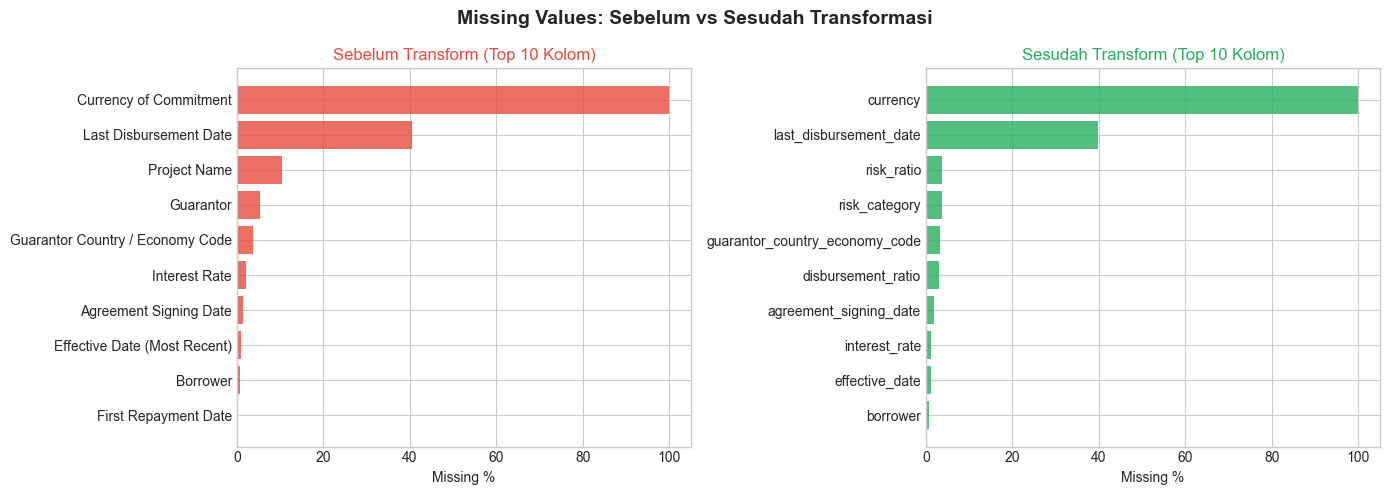


 Verifikasi transformasi selesai!


In [ ]:
# Visualisasi Missing Values Sebelum vs Sesudah
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Missing Values: Sebelum vs Sesudah Transformasi", fontsize=14, fontweight="bold")

mv_before = df_raw.isnull().mean().sort_values(ascending=False).head(10) * 100
axes[0].barh(mv_before.index[::-1], mv_before.values[::-1], color="#e74c3c", alpha=0.8)
axes[0].set_title("Sebelum Transform (Top 10 Kolom)", color="#e74c3c")
axes[0].set_xlabel("Missing %")

mv_after = df_clean.isnull().mean().sort_values(ascending=False).head(10) * 100
axes[1].barh(mv_after.index[::-1], mv_after.values[::-1], color="#27ae60", alpha=0.8)
axes[1].set_title("Sesudah Transform (Top 10 Kolom)", color="#27ae60")
axes[1].set_xlabel("Missing %")

plt.tight_layout()

# SAVE VALIDATION REPORT
plt.savefig(DATA_DIR / "missing_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n Verifikasi transformasi selesai!")

## 5. Load PostgreSQL Cloud (Supabase) <a id='5-load'></a>

### Desain Star Schema

```
         dim_time
             │
dim_country──┤
             ├── fact_loans (PARTITIONED BY approval_year)
             │
         dim_loan_type
```

### PostgreSQL Extensions yang Digunakan
| Extension | Fungsi |
|-----------|--------|
| `pg_stat_statements` | Monitoring & profiling query performa |
| `btree_gin` | GIN index untuk multi-column & tipe data kombinasi |
| `pg_trgm` | Trigram similarity search pada kolom teks (project_name, borrower) |


In [ ]:
# Memuat koneksi engine SQLAlchemy ke PostgreSQL
def get_engine(database_url: str = DATABASE_URL):
    try:
        engine = create_engine(
            database_url,
            pool_size=5,
            max_overflow=10,
            pool_pre_ping=True,
            connect_args={
                "connect_timeout": 30,
                "options"        : "-c statement_timeout=120000"
            }
        )
        with engine.connect() as conn:
            result = conn.execute(text("SELECT version()"))
            ver    = result.fetchone()[0]
            logger.info(f"✅ Koneksi berhasil: {ver[:60]}")
        return engine
    except Exception as e:
        logger.error(f"❌ Koneksi gagal: {e}")
        raise

engine = get_engine()

--- Logging error ---
Traceback (most recent call last):
  File "c:\Users\ILMIN\AppData\Local\Programs\Python\Python312\Lib\logging\__init__.py", line 1163, in emit
    stream.write(msg + self.terminator)
  File "c:\Users\ILMIN\AppData\Local\Programs\Python\Python312\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u2705' in position 31: character maps to <undefined>
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\ILMIN\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\ILMIN\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\ILMIN\A

In [ ]:
# DDL — STAR SCHEMA (CREATE TABLES)
# Menggunakan Partisi, Extension, dan fitur PostgreSQL lanjut

DDL_EXTENSIONS = """
-- AKTIFKAN EXTENSIONS PostgreSQL untuk OLAP
-- Wajib dijalankan oleh superuser / role dengan CREATE EXTENSION privilege

-- 1. pg_stat_statements: untuk profiling & monitoring semua query
CREATE EXTENSION IF NOT EXISTS pg_stat_statements;

-- 2. btree_gin: memungkinkan GIN index pada tipe data biasa (int, text, dll.)
--    Berguna untuk multi-column index pada fact_loans
CREATE EXTENSION IF NOT EXISTS btree_gin;

-- 3. pg_trgm: trigram similarity untuk full-text search pada project_name & borrower
CREATE EXTENSION IF NOT EXISTS pg_trgm;
"""

DDL_TABLES = """
-- DIMENSION: dim_time
DROP TABLE IF EXISTS dim_time CASCADE;
CREATE TABLE dim_time (
    time_id      SERIAL PRIMARY KEY,
    full_date    DATE,
    year         SMALLINT   NOT NULL,
    quarter      SMALLINT   NOT NULL CHECK (quarter BETWEEN 1 AND 4),
    month        SMALLINT   NOT NULL CHECK (month   BETWEEN 1 AND 12),
    month_name   VARCHAR(15),
    year_quarter VARCHAR(10),
    year_month   VARCHAR(10)
);
CREATE INDEX idx_dim_time_year    ON dim_time(year);
CREATE INDEX idx_dim_time_quarter ON dim_time(quarter);


-- DIMENSION: dim_country
DROP TABLE IF EXISTS dim_country CASCADE;
CREATE TABLE dim_country (
    country_id   SERIAL PRIMARY KEY,
    country_code VARCHAR(10) UNIQUE,
    country_name VARCHAR(200),
    region       VARCHAR(100),
    income_group VARCHAR(100)
);
CREATE INDEX idx_dim_country_code   ON dim_country(country_code);
CREATE INDEX idx_dim_country_region ON dim_country(region);


-- DIMENSION: dim_loan_type
DROP TABLE IF EXISTS dim_loan_type CASCADE;
CREATE TABLE dim_loan_type (
    loan_type_id   SERIAL PRIMARY KEY,
    loan_type      VARCHAR(200) UNIQUE,
    loan_category  VARCHAR(100),
    risk_profile   VARCHAR(50),   -- Low / Medium / High (berdasarkan jenis loan)
    interest_range VARCHAR(50)    -- Fixed / Variable / Blended
);


-- FACT TABLE: fact_loans (PARTITIONED BY approval_year)
DROP TABLE IF EXISTS fact_loans CASCADE;
CREATE TABLE fact_loans (
    loan_id                   SERIAL,
    loan_number               VARCHAR(50),
    project_id                VARCHAR(50),
    project_name              TEXT,
    borrower                  TEXT,
    loan_status               VARCHAR(100),
    currency                  VARCHAR(20),
    country_id                INT REFERENCES dim_country(country_id),
    loan_type_id              INT REFERENCES dim_loan_type(loan_type_id),
    approval_time_id          INT REFERENCES dim_time(time_id),
    board_approval_date       DATE,
    effective_date            DATE,
    closed_date               DATE,
    last_disbursement_date    DATE,
    original_principal_amount NUMERIC(20,2),
    disbursed_amount          NUMERIC(20,2),
    cancelled_amount          NUMERIC(20,2),
    undisbursed_amount        NUMERIC(20,2),
    repaid_amount             NUMERIC(20,2),
    due_amount                NUMERIC(20,2),
    loans_held                NUMERIC(20,2),
    interest_rate             NUMERIC(8,4),
    disbursement_ratio        NUMERIC(6,4),
    risk_ratio                NUMERIC(6,4),
    risk_category             VARCHAR(50),
    loan_age_years            NUMERIC(8,2),
    approval_year             SMALLINT,
    PRIMARY KEY (loan_id, approval_year)
) PARTITION BY RANGE (approval_year);

-- Partisi per periode (6 partisi)
CREATE TABLE fact_loans_before_2000 PARTITION OF fact_loans FOR VALUES FROM (MINVALUE) TO (2000);
CREATE TABLE fact_loans_2000_2005   PARTITION OF fact_loans FOR VALUES FROM (2000) TO (2005);
CREATE TABLE fact_loans_2005_2010   PARTITION OF fact_loans FOR VALUES FROM (2005) TO (2010);
CREATE TABLE fact_loans_2010_2015   PARTITION OF fact_loans FOR VALUES FROM (2010) TO (2015);
CREATE TABLE fact_loans_2015_2020   PARTITION OF fact_loans FOR VALUES FROM (2015) TO (2020);
CREATE TABLE fact_loans_2020_plus   PARTITION OF fact_loans FOR VALUES FROM (2020) TO (MAXVALUE);

-- Index B-tree standar
CREATE INDEX idx_fact_loan_status  ON fact_loans(loan_status);
CREATE INDEX idx_fact_country      ON fact_loans(country_id);
CREATE INDEX idx_fact_approval_yr  ON fact_loans(approval_year);
CREATE INDEX idx_fact_risk_cat     ON fact_loans(risk_category);

-- Index GIN dengan btree_gin extension (multi-column OLAP index)
CREATE INDEX idx_fact_gin_olap     ON fact_loans USING GIN (loan_status, risk_category);

-- Index Trigram (pg_trgm) untuk full-text search
CREATE INDEX idx_fact_trgm_project ON fact_loans USING GIN (project_name gin_trgm_ops);
CREATE INDEX idx_fact_trgm_borrower ON fact_loans USING GIN (borrower gin_trgm_ops);
"""

def run_ddl(engine, ddl: str, label: str):
    statements = [s.strip() for s in ddl.split(';') if s.strip()]
    with engine.begin() as conn:
        for stmt in statements:
            try:
                conn.execute(text(stmt))
            except Exception as e:
                print(f"  ⚠️  [{label}] Peringatan: {str(e)[:100]}")
    print(f"✅ DDL '{label}' selesai dieksekusi ({len(statements)} statements)")

# Jalankan Extensions terlebih dahulu
run_ddl(engine, DDL_EXTENSIONS, "Extensions")

# Verifikasi extensions aktif
with engine.connect() as conn:
    result = conn.execute(text(
        """SELECT extname, extversion FROM pg_extension
           WHERE extname IN ('pg_stat_statements', 'btree_gin', 'pg_trgm')
           ORDER BY extname"""
    ))
    ext_list = result.fetchall()

print("\n Extensions PostgreSQL yang Aktif:")
if ext_list:
    for row in ext_list:
        print(f"   ✅ {row[0]:25s} (v{row[1]})")
else:
    print("   ⚠️  Extensions belum aktif, pastikan menggunakan Supabase dengan role yang sesuai")

# Jalankan DDL Tabel
run_ddl(engine, DDL_TABLES, "Tables & Indexes")
print("\n✅ Star Schema berhasil dibuat di PostgreSQL!")


✅ DDL 'Extensions' selesai dieksekusi (3 statements)

 Extensions PostgreSQL yang Aktif:
   ✅ btree_gin                 (v1.3)
   ✅ pg_stat_statements        (v1.11)
   ✅ pg_trgm                   (v1.6)
✅ DDL 'Tables & Indexes' selesai dieksekusi (25 statements)

✅ Star Schema berhasil dibuat di PostgreSQL!


In [ ]:
# PostgreSQL Data Warehouse
class DimensionLoader:
    #Memuat data dimensi ke PostgreSQL

    def __init__(self, df: pd.DataFrame, engine):
        self.df     = df
        self.engine = engine

    def load_dim_time(self) -> pd.DataFrame:
        date_col = next(
            (c for c in ["board_approval_date", "end_of_period"] if c in self.df.columns), None
        )
        if date_col is None:
            logger.warning("Kolom tanggal tidak ditemukan untuk dim_time")
            return pd.DataFrame()

        dates              = self.df[date_col].dropna().drop_duplicates()
        dim                = pd.DataFrame({"full_date": dates})
        dim["year"]        = dim["full_date"].dt.year.astype(int)
        dim["quarter"]     = dim["full_date"].dt.quarter.astype(int)
        dim["month"]       = dim["full_date"].dt.month.astype(int)
        dim["month_name"]  = dim["full_date"].dt.strftime("%B")
        dim["year_quarter"]= dim["year"].astype(str) + "-Q" + dim["quarter"].astype(str)
        dim["year_month"]  = dim["full_date"].dt.strftime("%Y-%m")
        dim                = dim.drop_duplicates(subset=["full_date"]).reset_index(drop=True)

        dim.to_sql("dim_time", self.engine, if_exists="append", index=False,
                   method="multi", chunksize=500)
        logger.info(f"[LOAD] ✅ dim_time: {len(dim):,} baris")
        return dim

    def load_dim_country(self) -> pd.DataFrame:
        cols = {}
        for col in ["country_code", "country_name", "region"]:
            if col in self.df.columns:
                cols[col] = self.df[col]
        if not cols:
            logger.warning("Kolom negara tidak ditemukan")
            return pd.DataFrame()

        dim                = pd.DataFrame(cols).drop_duplicates(subset=["country_code"]).reset_index(drop=True)
        dim["income_group"]= "Unknown"
        dim.to_sql("dim_country", self.engine, if_exists="append", index=False,
                   method="multi", chunksize=500)
        logger.info(f"[LOAD] ✅ dim_country: {len(dim):,} baris")
        return dim

    def load_dim_loan_type(self) -> pd.DataFrame:
        if "loan_type" not in self.df.columns:
            logger.warning("Kolom loan_type tidak ditemukan")
            return pd.DataFrame()

        dim = self.df[["loan_type"]].drop_duplicates().dropna().reset_index(drop=True)

        def classify_category(lt):
            lt_lower = str(lt).lower()
            if "invest" in lt_lower:   return "Investment"
            if "dpl" in lt_lower:      return "Development Policy"
            if "p4r" in lt_lower:      return "Program for Results"
            return "Other"

        def classify_risk_profile(lt):
            """Klasifikasi profil risiko berdasarkan jenis pinjaman."""
            lt_lower = str(lt).lower()
            if "development policy" in lt_lower or "dpl" in lt_lower:
                return "High"       # DPL cenderung terkait kebijakan makro berisiko
            if "p4r" in lt_lower or "program for result" in lt_lower:
                return "Medium"
            if "invest" in lt_lower:
                return "Low"
            return "Medium"

        def classify_interest_range(lt):
            lt_lower = str(lt).lower()
            if "fixed" in lt_lower:    return "Fixed"
            if "variable" in lt_lower: return "Variable"
            return "Blended"

        dim["loan_category"]  = dim["loan_type"].apply(classify_category)
        dim["risk_profile"]   = dim["loan_type"].apply(classify_risk_profile)
        dim["interest_range"] = dim["loan_type"].apply(classify_interest_range)

        dim.to_sql("dim_loan_type", self.engine, if_exists="append", index=False,
                   method="multi", chunksize=500)
        logger.info(f"[LOAD] ✅ dim_loan_type: {len(dim):,} baris (+ risk_profile, interest_range)")
        return dim

    def load_all(self) -> dict:
        logger.info("[LOAD] Memuat semua tabel dimensi...")
        return {
            "dim_time"      : self.load_dim_time(),
            "dim_country"   : self.load_dim_country(),
            "dim_loan_type" : self.load_dim_loan_type(),
        }

In [ ]:
# EXECUTE DIMENSION LOAD
dim_loader = DimensionLoader(df_clean, engine)
dims       = dim_loader.load_all()

2026-06-05 09:53:06,957 [INFO] [LOAD] Memuat semua tabel dimensi...
--- Logging error ---
Traceback (most recent call last):
  File "c:\Users\ILMIN\AppData\Local\Programs\Python\Python312\Lib\logging\__init__.py", line 1163, in emit
    stream.write(msg + self.terminator)
  File "c:\Users\ILMIN\AppData\Local\Programs\Python\Python312\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u2705' in position 38: character maps to <undefined>
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\ILMIN\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\ILMIN\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", li

In [ ]:
# DIMENSION LOAD SUMMARY
print("Semua dimensi berhasil diload!")
for name, df_dim in dims.items():
    if len(df_dim) > 0:
        print(f"   {name:20s}: {len(df_dim):,} baris")

Semua dimensi berhasil diload!
   dim_time            : 3,601 baris
   dim_country         : 148 baris
   dim_loan_type       : 14 baris


In [ ]:
# Tampilkan sample dim_loan_type dengan kolom baru
print("\n Sample dim_loan_type (dengan kolom risk_profile & interest_range):")
if len(dims["dim_loan_type"]) > 0:
    display(dims["dim_loan_type"].head(10))


 Sample dim_loan_type (dengan kolom risk_profile & interest_range):


,loan_type,loan_category,risk_profile,interest_range
0,Non Pool,Other,Medium,Blended
1,Pool Loan,Other,Medium,Blended
2,Bloan,Other,Medium,Blended
3,Fsl,Other,Medium,Blended
4,Npl,Other,Medium,Blended
5,Cpl,Other,Medium,Blended
6,Scpd,Other,Medium,Blended
7,Scpm,Other,Medium,Blended
8,Scpy,Other,Medium,Blended
9,Scl,Other,Medium,Blended


In [ ]:
# FACT TABLE LOADER
def load_fact_loans(df: pd.DataFrame, engine, chunksize: int = 1000) -> int:
    before = len(df)
    df     = df.dropna(subset=["approval_year"]).copy()
    dropped = before - len(df)
    if dropped > 0:
        logger.warning(f"[LOAD] ⚠️  {dropped:,} baris dibuang (approval_year = null)")

    df["approval_year"] = df["approval_year"].astype(int)
    logger.info(f"[LOAD] Memulai load fact_loans — {len(df):,} baris...")

    # Ambil mapping FK dari dimensi
    with engine.connect() as conn:
        dim_country   = pd.read_sql("SELECT country_id, country_code FROM dim_country", conn)
        dim_loan_type = pd.read_sql("SELECT loan_type_id, loan_type FROM dim_loan_type", conn)
        dim_time      = pd.read_sql(
            "SELECT time_id, full_date FROM dim_time", conn, parse_dates=["full_date"]
        )

    df_fact = df.copy()

    if "country_code" in df_fact.columns and len(dim_country) > 0:
        df_fact = df_fact.merge(dim_country, on="country_code", how="left")

    if "loan_type" in df_fact.columns and len(dim_loan_type) > 0:
        df_fact = df_fact.merge(dim_loan_type, on="loan_type", how="left")

    date_col = next((c for c in ["board_approval_date"] if c in df_fact.columns), None)
    if date_col and len(dim_time) > 0:
        dim_time["full_date"]  = pd.to_datetime(dim_time["full_date"])
        df_fact[date_col]      = pd.to_datetime(df_fact[date_col])
        df_fact = df_fact.merge(
            dim_time.rename(columns={"full_date": date_col, "time_id": "approval_time_id"}),
            on=date_col, how="left"
        )

    fact_cols = [
        "loan_number", "project_id", "project_name", "borrower",
        "loan_status", "currency",
        "country_id", "loan_type_id", "approval_time_id",
        "board_approval_date", "effective_date", "closed_date", "last_disbursement_date",
        "original_principal_amount", "disbursed_amount", "cancelled_amount",
        "undisbursed_amount", "repaid_amount", "due_amount",
        "loans_held", "interest_rate",
        "disbursement_ratio", "risk_ratio", "risk_category",
        "loan_age_years", "approval_year",
    ]
    existing_cols = [c for c in fact_cols if c in df_fact.columns]
    df_fact       = df_fact[existing_cols].copy()

    for col in ["board_approval_date", "effective_date", "closed_date", "last_disbursement_date"]:
        if col in df_fact.columns:
            df_fact[col] = pd.to_datetime(df_fact[col], errors="coerce")

    # Chunked loading
    total  = 0
    chunks = [df_fact.iloc[i:i+chunksize] for i in range(0, len(df_fact), chunksize)]
    for chunk in tqdm(chunks, desc="Loading fact_loans"):
        chunk.to_sql("fact_loans", engine, if_exists="append", index=False, method="multi")
        total += len(chunk)

    logger.info(f"[LOAD] ✅ fact_loans: {total:,} baris berhasil diload!")
    return total


n_loaded = load_fact_loans(df_clean, engine)
print(f"\n✅ Load selesai! {n_loaded:,} baris berhasil dimasukkan ke fact_loans")


--- Logging error ---
Traceback (most recent call last):
  File "c:\Users\ILMIN\AppData\Local\Programs\Python\Python312\Lib\logging\__init__.py", line 1163, in emit
    stream.write(msg + self.terminator)
  File "c:\Users\ILMIN\AppData\Local\Programs\Python\Python312\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode characters in position 41-42: character maps to <undefined>
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\ILMIN\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\ILMIN\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\ILMIN\AppDat


✅ Load selesai! 9,768 baris berhasil dimasukkan ke fact_loans


## 6. OLAP Optimization Materialized View, Index & Extensions <a id='6-olap'></a>

### PostgreSQL Extensions yang Digunakan
| Extension | Tujuan OLAP |
|-----------|-------------|
| `pg_stat_statements` | Profiling & audit semua query yang dieksekusi |
| `btree_gin` | GIN multi-column index pada fact_loans untuk filter kombinasi |
| `pg_trgm` | Full-text similarity search pada project_name & borrower |

### Optimasi OLAP
- **Partisi** (`PARTITION BY RANGE`) berdasarkan `approval_year` — 6 partisi
- **Materialized View** (5 view) untuk query agregasi OLAP
- **Index** pada setiap MV dan kolom kunci fact table


In [ ]:
MATERIALIZED_VIEWS = {
    "mv_loan_by_region_year": """
        CREATE MATERIALIZED VIEW IF NOT EXISTS mv_loan_by_region_year AS
        SELECT
            dc.region,
            dt.year,
            dt.quarter,
            COUNT(f.loan_id)                     AS total_loans,
            SUM(f.original_principal_amount)     AS total_commitment_usd,
            SUM(f.disbursed_amount)              AS total_disbursed_usd,
            SUM(f.due_amount)                    AS total_outstanding_usd,
            SUM(f.repaid_amount)                 AS total_repaid_usd,
            AVG(f.disbursement_ratio)            AS avg_disbursement_ratio,
            AVG(f.risk_ratio)                    AS avg_risk_ratio,
            AVG(f.interest_rate)                 AS avg_interest_rate
        FROM fact_loans f
        JOIN dim_country dc ON f.country_id       = dc.country_id
        JOIN dim_time    dt ON f.approval_time_id = dt.time_id
        GROUP BY dc.region, dt.year, dt.quarter
        ORDER BY dt.year DESC, total_commitment_usd DESC
        WITH DATA
    """,

    "mv_top_countries": """
        CREATE MATERIALIZED VIEW IF NOT EXISTS mv_top_countries AS
        SELECT
            dc.country_name,
            dc.country_code,
            dc.region,
            COUNT(f.loan_id)                     AS total_loans,
            SUM(f.original_principal_amount)     AS total_commitment_usd,
            SUM(f.disbursed_amount)              AS total_disbursed_usd,
            SUM(f.due_amount)                    AS total_outstanding_usd,
            AVG(f.risk_ratio)                    AS avg_risk_ratio,
            SUM(CASE WHEN f.loan_status = 'Active' THEN 1 ELSE 0 END) AS active_loans
        FROM fact_loans f
        JOIN dim_country dc ON f.country_id = dc.country_id
        GROUP BY dc.country_name, dc.country_code, dc.region
        ORDER BY total_commitment_usd DESC
        WITH DATA
    """,

    "mv_risk_portfolio": """
        CREATE MATERIALIZED VIEW IF NOT EXISTS mv_risk_portfolio AS
        SELECT
            f.risk_category,
            dc.region,
            dt.year,
            COUNT(f.loan_id)                 AS total_loans,
            SUM(f.original_principal_amount) AS total_amount_usd,
            SUM(f.due_amount)                AS total_at_risk_usd,
            AVG(f.interest_rate)             AS avg_interest_rate
        FROM fact_loans f
        JOIN dim_country dc ON f.country_id       = dc.country_id
        JOIN dim_time    dt ON f.approval_time_id = dt.time_id
        WHERE f.risk_category IS NOT NULL
        GROUP BY f.risk_category, dc.region, dt.year
        ORDER BY total_at_risk_usd DESC
        WITH DATA
    """,

    "mv_quarterly_trend": """
        CREATE MATERIALIZED VIEW IF NOT EXISTS mv_quarterly_trend AS
        SELECT
            dt.year_quarter,
            dt.year,
            dt.quarter,
            COUNT(f.loan_id)                     AS new_loans,
            SUM(f.original_principal_amount)     AS new_commitment_usd,
            SUM(f.disbursed_amount)              AS disbursed_usd,
            AVG(f.original_principal_amount)     AS avg_loan_size_usd,
            SUM(CASE WHEN f.loan_status = 'Active'
                THEN f.original_principal_amount ELSE 0 END) AS active_portfolio_usd
        FROM fact_loans f
        JOIN dim_time dt ON f.approval_time_id = dt.time_id
        GROUP BY dt.year_quarter, dt.year, dt.quarter
        ORDER BY dt.year, dt.quarter
        WITH DATA
    """,

    "mv_loan_status_summary": """
        CREATE MATERIALIZED VIEW IF NOT EXISTS mv_loan_status_summary AS
        SELECT
            f.loan_status,
            dc.region,
            COUNT(f.loan_id)                 AS total_loans,
            SUM(f.original_principal_amount) AS total_amount_usd,
            AVG(f.loan_age_years)            AS avg_loan_age_years
        FROM fact_loans f
        JOIN dim_country dc ON f.country_id = dc.country_id
        WHERE f.loan_status IS NOT NULL
        GROUP BY f.loan_status, dc.region
        ORDER BY total_amount_usd DESC
        WITH DATA
    """,
}

MV_INDEXES = [
    "CREATE INDEX IF NOT EXISTS idx_mv_region_year ON mv_loan_by_region_year(region, year)",
    "CREATE INDEX IF NOT EXISTS idx_mv_country     ON mv_top_countries(country_code)",
    "CREATE INDEX IF NOT EXISTS idx_mv_risk        ON mv_risk_portfolio(risk_category, year)",
    "CREATE INDEX IF NOT EXISTS idx_mv_trend       ON mv_quarterly_trend(year, quarter)",
]


def create_materialized_views(engine) -> None:
    with engine.begin() as conn:
        for name, sql in tqdm(MATERIALIZED_VIEWS.items(), desc="Membuat Materialized Views"):
            try:
                conn.execute(text(sql))
                logger.info(f"[MV] ✅ {name} berhasil dibuat")
            except Exception as e:
                logger.error(f"[MV] ❌ {name}: {e}")
        for idx_sql in MV_INDEXES:
            try:
                conn.execute(text(idx_sql))
            except Exception as e:
                logger.warning(f"[MV Index] {e}")
    logger.info("[MV] ✅ Semua Materialized Views berhasil dibuat!")


create_materialized_views(engine)
print("\n✅ Materialized Views berhasil dibuat:")
for mv in MATERIALIZED_VIEWS.keys():
    print(f"   - {mv}")


Membuat Materialized Views:   0%|          | 0/5 [00:00<?, ?it/s]--- Logging error ---
Traceback (most recent call last):
  File "c:\Users\ILMIN\AppData\Local\Programs\Python\Python312\Lib\logging\__init__.py", line 1163, in emit
    stream.write(msg + self.terminator)
  File "c:\Users\ILMIN\AppData\Local\Programs\Python\Python312\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u2705' in position 36: character maps to <undefined>
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\ILMIN\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\ILMIN\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 


✅ Materialized Views berhasil dibuat:
   - mv_loan_by_region_year
   - mv_top_countries
   - mv_risk_portfolio
   - mv_quarterly_trend
   - mv_loan_status_summary


## 7. Atoti DataMart & Cube (OLAP) <a id='7-atoti'></a>

Proses pembuatan DataMart menggunakan Atoti:
- **Store** : tabel fakta dimuat ke dalam sesi Atoti
- **Cube** : OLAP cube dibuat dari store
- **Measures** : 11 custom measures untuk eksplorasi OLAP


In [ ]:
import atoti as tt

# Load data dari PostgreSQL ke DataFrame untuk Atoti
with engine.connect() as conn:
    df_fact_atoti = pd.read_sql("""
        SELECT
            f.loan_number,
            f.project_id,
            f.project_name,
            f.borrower,
            f.loan_status,
            f.currency,
            dc.country_name,
            dc.country_code,
            dc.region,
            COALESCE(dlt.loan_type, 'Unknown')   AS loan_type,
            f.board_approval_date,
            ti.year                              AS approval_year,
            ti.quarter                           AS approval_quarter,
            ti.month                             AS approval_month,
            ti.year_quarter,
            f.original_principal_amount,
            f.disbursed_amount,
            f.cancelled_amount,
            f.undisbursed_amount,
            f.repaid_amount,
            f.due_amount,
            f.interest_rate,
            f.disbursement_ratio,
            f.risk_ratio,
            COALESCE(f.risk_category, 'Unknown') AS risk_category,
            f.loan_age_years
        FROM fact_loans f
        LEFT JOIN dim_country   dc  ON f.country_id       = dc.country_id
        LEFT JOIN dim_loan_type dlt ON f.loan_type_id     = dlt.loan_type_id
        LEFT JOIN dim_time      ti  ON f.approval_time_id = ti.time_id
    """, conn, parse_dates=["board_approval_date"])

print(f"✅ Data dimuat dari PostgreSQL: {len(df_fact_atoti):,} baris")
display(df_fact_atoti.head(3))


✅ Data dimuat dari PostgreSQL: 9,768 baris


,loan_number,project_id,project_name,borrower,loan_status,currency,country_name,country_code,region,loan_type,board_approval_date,approval_year,approval_quarter,approval_month,year_quarter,original_principal_amount,disbursed_amount,cancelled_amount,undisbursed_amount,repaid_amount,due_amount,interest_rate,disbursement_ratio,risk_ratio,risk_category,loan_age_years
0,IBRD10001,P037456,SHIPPING IV,None,Repaid,None,Netherlands,Nl,Europe And Central Asia,Non Pool,1948-05-21,1948,2,5,1948-Q2,"2,000,000.00","2,000,000.00",0.00,0.00,0.00,0.00,4.00,1.00,0.00,Low Risk,0.20
1,IBRD10011,P006214,POWER AND TELEPHONE,Minist?o da Fazenda,Repaid,None,Brazil,Br,Latin America And Caribbean,Non Pool,1949-01-27,1949,1,1,1949-Q1,"75,000,000.00","75,000,000.00",0.00,0.00,"70,971,588.97",0.00,5.00,1.00,0.00,Low Risk,4.93
2,IBRD10012,P006214,POWER AND TELEPHONE,Minist?o da Fazenda,Repaid,None,Brazil,Br,Latin America And Caribbean,Non Pool,1951-01-16,1951,1,1,1951-Q1,"15,000,000.00","15,000,000.00",0.00,0.00,"15,000,000.00",0.00,4.00,1.00,0.00,Low Risk,3.96


In [ ]:
# Buat sesi Atoti & OLAP Cube
session = tt.Session.start()

loans_store = session.read_pandas(
    df_fact_atoti,
    table_name="loans",
    keys=["loan_number"]
)

cube = session.create_cube(loans_store)
m    = cube.measures
h    = cube.hierarchies
l    = cube.levels

print("✅ Cube berhasil dibuat!")
print(f"   Records     : {len(df_fact_atoti):,}")
print(f"   Hierarchies : {len(h)}")
print("\nDefault measures:")
for mname in list(m)[:8]:
    print(f"  - {mname}")


2026-06-05 09:54:15,509 [INFO] HTTP Request: GET http://localhost:65103/versions/rest "HTTP/1.1 200 "
2026-06-05 09:54:15,534 [INFO] HTTP Request: GET http://localhost:65103/activeviam/pivot/rest/v10/ping "HTTP/1.1 200 "
2026-06-05 09:54:15,816 [INFO] HTTP Request: GET http://localhost:65103/atoti/rest/v2/py4j/configuration "HTTP/1.1 200 "
2026-06-05 09:54:15,825 [INFO] Callback Server Starting
2026-06-05 09:54:15,833 [INFO] Socket listening on ('127.0.0.1', 65110)
2026-06-05 09:54:17,374 [INFO] HTTP Request: POST http://localhost:65103/graphql "HTTP/1.1 200 "
2026-06-05 09:54:17,453 [INFO] HTTP Request: POST http://localhost:65103/graphql "HTTP/1.1 200 "
2026-06-05 09:54:21,918 [INFO] HTTP Request: POST http://localhost:65103/graphql "HTTP/1.1 200 "
2026-06-05 09:54:21,933 [INFO] HTTP Request: POST http://localhost:65103/graphql "HTTP/1.1 200 "
2026-06-05 09:54:22,313 [INFO] HTTP Request: POST http://localhost:65103/graphql "HTTP/1.1 200 "
2026-06-05 09:54:22,317 [INFO] Closing down c

✅ Cube berhasil dibuat!
   Records     : 9,768
   Hierarchies : 13

Default measures:


2026-06-05 09:54:22,708 [INFO] HTTP Request: POST http://localhost:65103/graphql "HTTP/1.1 200 "
2026-06-05 09:54:22,774 [INFO] HTTP Request: POST http://localhost:65103/graphql "HTTP/1.1 200 "


  - approval_month.MEAN
  - approval_month.SUM
  - approval_quarter.MEAN
  - approval_quarter.SUM
  - approval_year.MEAN
  - approval_year.SUM
  - cancelled_amount.MEAN
  - cancelled_amount.SUM


In [ ]:
# DEFINISI MEASURES OLAP KUSTOM (11 measures)

m = cube.measures

# Measures Agregasi Utama
m["Total Commitment (USD)"]  = m["original_principal_amount.SUM"]
m["Total Disbursed (USD)"]   = m["disbursed_amount.SUM"]
m["Total Outstanding (USD)"] = m["due_amount.SUM"]
m["Total Repaid (USD)"]      = m["repaid_amount.SUM"]

# Measures Rata-rata
m["Avg Disbursement Rate (%)"] = m["disbursement_ratio.MEAN"] * 100
m["Avg Risk Ratio (%)"]        = m["risk_ratio.MEAN"] * 100
m["Avg Interest Rate (%)"]     = m["interest_rate.MEAN"]
m["Avg Loan Age (Years)"]      = m["loan_age_years.MEAN"]

# Measures Turunan (rasio portofolio)
m["Disbursement Ratio (%)"] = (m["Total Disbursed (USD)"]   / m["Total Commitment (USD)"]) * 100
m["Outstanding Ratio (%)"]  = (m["Total Outstanding (USD)"] / m["Total Commitment (USD)"]) * 100
m["Repayment Ratio (%)"]    = (m["Total Repaid (USD)"]      / m["Total Commitment (USD)"]) * 100

print("✅ 11 Measures OLAP berhasil didefinisikan:")
custom_measures = [
    "Total Commitment (USD)", "Total Disbursed (USD)", "Total Outstanding (USD)",
    "Total Repaid (USD)", "Avg Disbursement Rate (%)", "Avg Risk Ratio (%)",
    "Avg Interest Rate (%)", "Avg Loan Age (Years)",
    "Disbursement Ratio (%)", "Outstanding Ratio (%)", "Repayment Ratio (%)"
]
for name in custom_measures:
    print(f"  ✔ {name}")


2026-06-05 09:54:22,853 [INFO] HTTP Request: POST http://localhost:65103/graphql "HTTP/1.1 200 "
2026-06-05 09:54:22,975 [INFO] HTTP Request: POST http://localhost:65103/graphql "HTTP/1.1 200 "
2026-06-05 09:54:23,080 [INFO] HTTP Request: POST http://localhost:65103/graphql "HTTP/1.1 200 "
2026-06-05 09:54:23,184 [INFO] HTTP Request: POST http://localhost:65103/graphql "HTTP/1.1 200 "
2026-06-05 09:54:23,259 [INFO] HTTP Request: POST http://localhost:65103/graphql "HTTP/1.1 200 "
2026-06-05 09:54:23,763 [INFO] HTTP Request: POST http://localhost:65103/graphql "HTTP/1.1 200 "
2026-06-05 09:54:23,856 [INFO] HTTP Request: POST http://localhost:65103/graphql "HTTP/1.1 200 "
2026-06-05 09:54:23,946 [INFO] HTTP Request: POST http://localhost:65103/graphql "HTTP/1.1 200 "
2026-06-05 09:54:24,023 [INFO] HTTP Request: POST http://localhost:65103/graphql "HTTP/1.1 200 "
2026-06-05 09:54:24,056 [INFO] HTTP Request: POST http://localhost:65103/graphql "HTTP/1.1 200 "
2026-06-05 09:54:24,179 [INFO]

✅ 11 Measures OLAP berhasil didefinisikan:
  ✔ Total Commitment (USD)
  ✔ Total Disbursed (USD)
  ✔ Total Outstanding (USD)
  ✔ Total Repaid (USD)
  ✔ Avg Disbursement Rate (%)
  ✔ Avg Risk Ratio (%)
  ✔ Avg Interest Rate (%)
  ✔ Avg Loan Age (Years)
  ✔ Disbursement Ratio (%)
  ✔ Outstanding Ratio (%)
  ✔ Repayment Ratio (%)


## 8. Atoti Widgets Visualisasi OLAP <a id='8-widgets'></a>

Akses dashboard Atoti melalui URL yang ditampilkan di bawah ini.  
Dashboard dapat digunakan untuk eksplorasi OLAP interaktif (drill-down, slice, dice).




In [ ]:
# Tampilkan informasi akses Atoti Dashboard
print("\nATOTI DATAMART INFORMASI AKSES \n")
print(f"\nSession URL  : {session.url}")
print(f"\nBuka browser dan akses URL di atas untuk dashboard OLAP interaktif.")
print(f"\nCube Summary:")
print(f"  Records    : {len(df_fact_atoti):,}")
print(f"  Measures   : {len(cube.measures)}")
print(f"  Hierarchies: {len(cube.hierarchies)}")

print("\nSemua Measures tersedia:")
for measure in cube.measures:
    print(f"  - {measure}")

2026-06-05 09:54:24,487 [INFO] HTTP Request: POST http://localhost:65103/graphql "HTTP/1.1 200 "
2026-06-05 09:54:24,526 [INFO] HTTP Request: POST http://localhost:65103/graphql "HTTP/1.1 200 "
2026-06-05 09:54:24,581 [INFO] HTTP Request: POST http://localhost:65103/graphql "HTTP/1.1 200 "



ATOTI DATAMART INFORMASI AKSES 


Session URL  : http://localhost:65103

Buka browser dan akses URL di atas untuk dashboard OLAP interaktif.

Cube Summary:
  Records    : 9,768
  Measures   : 39
  Hierarchies: 13

Semua Measures tersedia:
  - Avg Disbursement Rate (%)
  - Avg Interest Rate (%)
  - Avg Loan Age (Years)
  - Avg Risk Ratio (%)
  - Disbursement Ratio (%)
  - Outstanding Ratio (%)
  - Repayment Ratio (%)
  - Total Commitment (USD)
  - Total Disbursed (USD)
  - Total Outstanding (USD)
  - Total Repaid (USD)
  - approval_month.MEAN
  - approval_month.SUM
  - approval_quarter.MEAN
  - approval_quarter.SUM
  - approval_year.MEAN
  - approval_year.SUM
  - cancelled_amount.MEAN
  - cancelled_amount.SUM
  - contributors.COUNT
  - disbursed_amount.MEAN
  - disbursed_amount.SUM
  - disbursement_ratio.MEAN
  - disbursement_ratio.SUM
  - due_amount.MEAN
  - due_amount.SUM
  - interest_rate.MEAN
  - interest_rate.SUM
  - loan_age_years.MEAN
  - loan_age_years.SUM
  - original_principa

In [ ]:
# # Eksplorasi OLAP menggunakan Atoti API (alternatif widget)

# # Query 1: Total komitmen per region
# print("\nOLAP Query 1: Total Komitmen per Region:")
# try:
#     result_region = cube.query(
#         m["Total Commitment (USD)"],
#         m["Total Disbursed (USD)"],
#         m["Avg Risk Ratio (%)"],
#         levels=[l["loans"]["region"]]
#     )
#     display(result_region.sort_values("Total Commitment (USD)", ascending=False))
# except Exception as e:
#     print(f"  Info: {e}")
#     print("  Jalankan cell ini setelah cube berhasil dibuat.")

In [ ]:
# # Query 2: Tren per tahun
# print("\nOLAP Query 2: Tren Komitmen per Tahun:")
# try:
#     result_year = cube.query(
#         m["Total Commitment (USD)"],
#         m["Disbursement Ratio (%)"],
#         levels=[l["loans"]["approval_year"]]
#     )
#     display(result_year.sort_values("approval_year"))
# except Exception as e:
#     print(f"  Info: {e}")

### Fallback Visualisasi Plotly (Pengganti Atoti Widget)




In [ ]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def qdb(sql):
    with engine.connect() as conn:
        return pd.read_sql(sql, conn)

In [ ]:
# 1. KPI Summary
df_kpi = qdb("""
    SELECT
        ROUND(SUM(original_principal_amount)/1e9, 2) AS total_commitment_bn,
        ROUND(SUM(disbursed_amount)/1e9, 2)          AS total_disbursed_bn,
        ROUND(SUM(due_amount)/1e9, 2)                AS total_outstanding_bn,
        ROUND(SUM(repaid_amount)/1e9, 2)             AS total_repaid_bn,
        ROUND(AVG(interest_rate), 4)                 AS avg_interest,
        ROUND(AVG(risk_ratio)*100, 2)                AS avg_risk_pct
    FROM fact_loans
""")

fig_kpi = go.Figure()
labels = ["Total Commitment", "Total Disbursed", "Total Outstanding", "Total Repaid"]
values = [
    df_kpi["total_commitment_bn"].iloc[0],
    df_kpi["total_disbursed_bn"].iloc[0],
    df_kpi["total_outstanding_bn"].iloc[0],
    df_kpi["total_repaid_bn"].iloc[0],
]
colors = ["#1a237e", "#1565c0", "#e53935", "#2e7d32"]

for i, (label, value, color) in enumerate(zip(labels, values, colors)):
    fig_kpi.add_trace(go.Indicator(
        mode="number",
        value=float(value),
        title={"text": f"{label}<br><span style='font-size:12px'>Miliar USD</span>"},
        number={"prefix": "$", "suffix": "B", "font": {"color": color}},
        domain={"row": 0, "column": i}
    ))

fig_kpi.update_layout(
    grid={"rows": 1, "columns": 4},
    title="KPI Ringkasan Portofolio IBRD",
    height=200
)
fig_kpi.show()

In [ ]:
# 2. Bar Chart: Komitmen per Region
df_reg = qdb("""
    SELECT dc.region,
           COUNT(f.loan_id)                                AS total_loans,
           ROUND(SUM(f.original_principal_amount)/1e9, 2) AS commitment_bn,
           ROUND(SUM(f.disbursed_amount)/1e9, 2)          AS disbursed_bn,
           ROUND(SUM(f.due_amount)/1e9, 2)                AS outstanding_bn
    FROM fact_loans f
    JOIN dim_country dc ON f.country_id = dc.country_id
    WHERE f.original_principal_amount > 0
    GROUP BY dc.region
    ORDER BY commitment_bn DESC
""")

fig2 = px.bar(
    df_reg, x="region", y=["commitment_bn", "disbursed_bn", "outstanding_bn"],
    barmode="group",
    title="Komitmen, Disbursed & Outstanding per Region",
    labels={"value": "Miliar USD", "variable": "Kategori"},
    color_discrete_sequence=["#4f5cec", "#4c3aa4", "#3e42ac"]
)
fig2.show()

In [ ]:
# 3. Pie Chart: Distribusi Risk Category
df_risk = qdb("""
    SELECT risk_category, COUNT(*) AS total_loans
    FROM fact_loans
    WHERE risk_category IS NOT NULL AND risk_category != 'Unknown'
    GROUP BY risk_category
""")

fig3 = px.pie(
    df_risk, names="risk_category", values="total_loans",
    title="Distribusi Risk Category",
    color_discrete_sequence=["#7251df", "#5267c7", "#4351f0", "#154BED"]
)
fig3.show()

In [ ]:
# 4. Line Chart: Tren Komitmen per Tahun
df_trend = qdb("""
    SELECT dt.year,
           ROUND(SUM(f.original_principal_amount)/1e9, 3) AS commitment_bn,
           ROUND(AVG(f.interest_rate), 4)                 AS avg_interest,
           ROUND(AVG(f.risk_ratio)*100, 2)                AS avg_risk_pct
    FROM fact_loans f
    JOIN dim_time dt ON f.approval_time_id = dt.time_id
    WHERE dt.year >= 1990
    GROUP BY dt.year
    ORDER BY dt.year
""")

fig4 = make_subplots(specs=[[{"secondary_y": True}]])
fig4.add_trace(go.Scatter(
    x=df_trend["year"], y=df_trend["commitment_bn"],
    name="Komitmen (Miliar USD)", fill="tozeroy",
    line=dict(color="#1a237e", width=2.5)
), secondary_y=False)
fig4.add_trace(go.Scatter(
    x=df_trend["year"], y=df_trend["avg_risk_pct"],
    name="Avg Risk (%)", line=dict(color="#e53935", width=2, dash="dot")
), secondary_y=True)
fig4.update_layout(title="Tren Komitmen & Risiko per Tahun", height=400, hovermode="x unified")
fig4.update_yaxes(title_text="Komitmen (Miliar USD)", secondary_y=False)
fig4.update_yaxes(title_text="Avg Risk (%)", secondary_y=True)
fig4.show()

In [ ]:
# 5. Treemap: Komitmen per Negara
df_tree = qdb("""
    SELECT dc.region, dc.country_name,
           ROUND(SUM(f.original_principal_amount)/1e9, 2) AS commitment_bn
    FROM fact_loans f
    JOIN dim_country dc ON f.country_id = dc.country_id
    WHERE f.original_principal_amount > 0
    GROUP BY dc.region, dc.country_name
""")

fig5 = px.treemap(
    df_tree, path=["region", "country_name"], values="commitment_bn",
    color="commitment_bn", color_continuous_scale="Blues",
    title="Treemap Komitmen per Negara"
)
fig5.show()

In [ ]:
# 6. Pivot: Risiko per Region & Risk Category
df_pivot = qdb("""
    SELECT dc.region, f.risk_category,
           COUNT(f.loan_id)               AS total_loans,
           ROUND(SUM(f.due_amount)/1e9,2) AS outstanding_bn
    FROM fact_loans f
    JOIN dim_country dc ON f.country_id = dc.country_id
    WHERE f.risk_category IS NOT NULL AND f.risk_category != 'Unknown'
    GROUP BY dc.region, f.risk_category
""")

df_pivot_wide = df_pivot.pivot(index="region", columns="risk_category", values="outstanding_bn").fillna(0)
fig6 = px.imshow(
    df_pivot_wide, text_auto=True, aspect="auto",
    color_continuous_scale="RdYlGn_r",
    title="Heatmap Outstanding per Region × Risk Category"
)
fig6.show()

In [ ]:
# 7. Bar Chart: Cashflow per Tahun
df_cash = qdb("""
    SELECT dt.year,
           ROUND(SUM(f.disbursed_amount)/1e9, 3) AS disbursed_bn,
           ROUND(SUM(f.repaid_amount)/1e9, 3)    AS repaid_bn,
           ROUND(SUM(f.due_amount)/1e9, 3)       AS outstanding_bn
    FROM fact_loans f
    JOIN dim_time dt ON f.approval_time_id = dt.time_id
    WHERE dt.year >= 1990
    GROUP BY dt.year
    ORDER BY dt.year
""")

fig7 = px.bar(
    df_cash, x="year", y=["disbursed_bn", "repaid_bn", "outstanding_bn"],
    barmode="group",
    title="Cashflow Disbursed vs Repaid vs Outstanding per Tahun",
    labels={"value": "Miliar USD", "variable": "Kategori"},
    color_discrete_sequence=["#1565c0", "#2e7d32", "#e53935"]
)
fig7.show()

## 9. Hasil Analisis & Insight <a id='9-analisis'></a>

In [ ]:
def query_db(sql: str) -> pd.DataFrame:
    with engine.connect() as conn:
        return pd.read_sql(sql, conn)

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#1a237e", "#283593", "#3949ab", "#5c6bc0", "#7986cb", "#9fa8da", "#c5cae9", "#e8eaf6"]
ACCENT = "#e53935"


 Distribusi Komitmen IBRD per Region:


,region,total_loans,commitment_bn_usd,disbursed_bn_usd,outstanding_bn_usd,avg_interest
0,Latin America And Caribbean,2958,302.96,247.54,86.56,3.76
1,Europe And Central Asia,1915,211.69,160.85,65.41,3.18
2,East Asia And Pacific,1937,205.04,162.91,54.67,4.27
3,South Asia,604,105.46,72.50,27.74,2.90
4,Middle East And North Africa,785,53.65,41.90,17.44,4.16
5,"Mid East,North Africa,Afg,Pak",324,47.93,36.19,22.21,2.94
6,Africa,693,27.49,20.45,6.15,6.40
7,Eastern And Southern Africa,195,22.00,14.70,12.09,2.71
8,Western And Central Africa,40,1.20,0.84,0.34,4.37


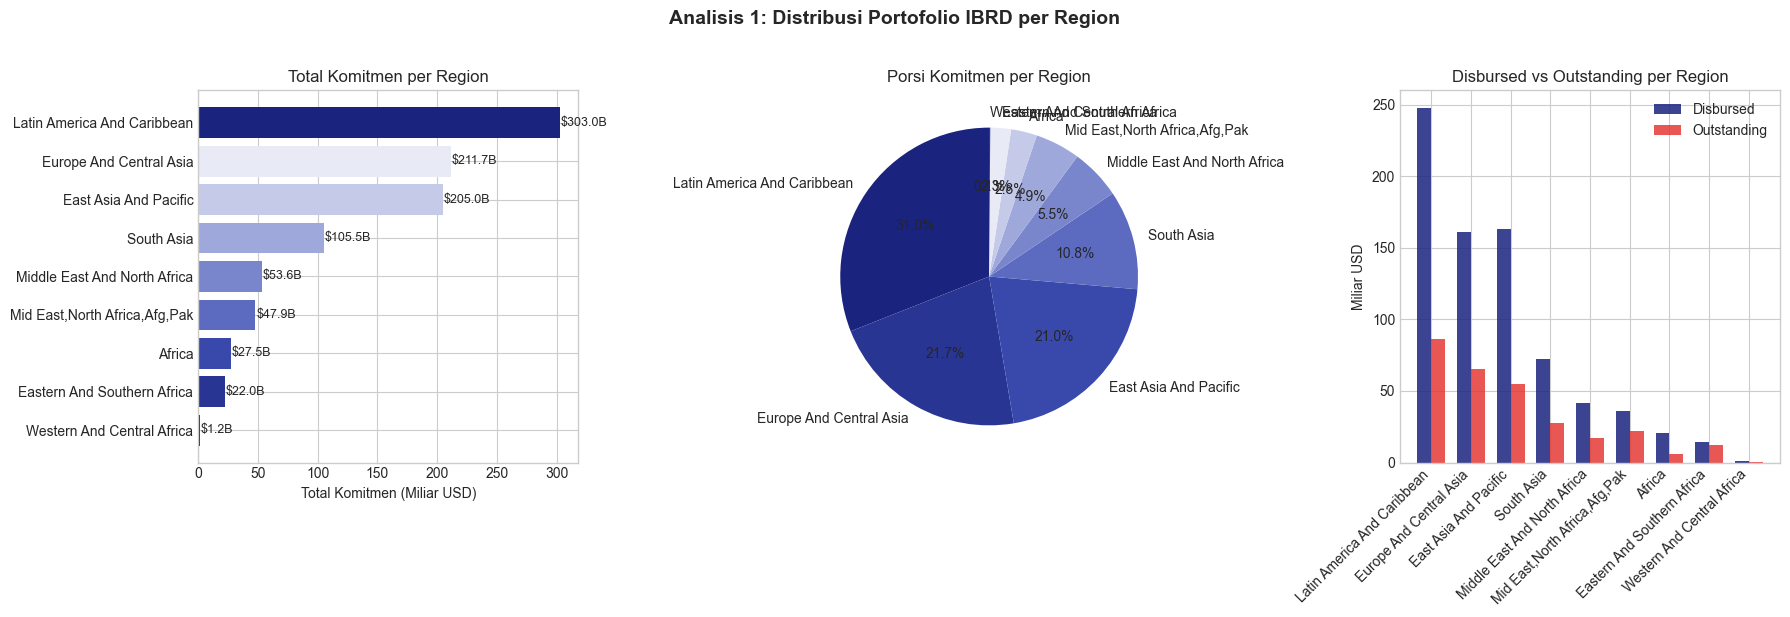


 INSIGHT 1: Region 'Latin America And Caribbean' mendominasi dengan
   komitmen USD 303.0 Miliar dari total 977.4B global.


In [ ]:
# ANALISIS 1: DISTRIBUSI KOMITMEN PER REGION

df_region = query_db("""
    SELECT
        dc.region,
        COUNT(*)                                       AS total_loans,
        ROUND(SUM(f.original_principal_amount)/1e9, 2) AS commitment_bn_usd,
        ROUND(SUM(f.disbursed_amount)/1e9, 2)          AS disbursed_bn_usd,
        ROUND(SUM(f.due_amount)/1e9, 2)                AS outstanding_bn_usd,
        ROUND(AVG(f.interest_rate), 4)                 AS avg_interest
    FROM fact_loans f
    JOIN dim_country dc ON f.country_id = dc.country_id
    WHERE f.original_principal_amount > 0
    GROUP BY dc.region
    ORDER BY commitment_bn_usd DESC
""")

print(" Distribusi Komitmen IBRD per Region:")
display(df_region)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Analisis 1: Distribusi Portofolio IBRD per Region",
             fontsize=14, fontweight="bold", y=1.02)

# Bar chart komitmen
ax = axes[0]
bars = ax.barh(df_region["region"][::-1], df_region["commitment_bn_usd"][::-1],
               color=COLORS[:len(df_region)])
ax.set_xlabel("Total Komitmen (Miliar USD)")
ax.set_title("Total Komitmen per Region")
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.5, bar.get_y() + bar.get_height()/2, f"${w:.1f}B", va="center", fontsize=9)

# Pie chart
ax = axes[1]
ax.pie(df_region["commitment_bn_usd"], labels=df_region["region"],
       autopct="%1.1f%%", colors=COLORS[:len(df_region)], startangle=90)
ax.set_title("Porsi Komitmen per Region")

# Disbursed vs Outstanding
ax   = axes[2]
x    = range(len(df_region))
w    = 0.35
ax.bar([i - w/2 for i in x], df_region["disbursed_bn_usd"],    w, label="Disbursed",    color="#1a237e", alpha=0.85)
ax.bar([i + w/2 for i in x], df_region["outstanding_bn_usd"],  w, label="Outstanding",  color=ACCENT,    alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(df_region["region"], rotation=45, ha="right")
ax.set_ylabel("Miliar USD")
ax.set_title("Disbursed vs Outstanding per Region")
ax.legend()

plt.tight_layout()
plt.savefig(DATA_DIR / "analisis_region.png", dpi=150, bbox_inches="tight")
plt.show()

top_region = df_region.iloc[0]
print(f"\n INSIGHT 1: Region '{top_region['region']}' mendominasi dengan")
print(f"   komitmen USD {top_region['commitment_bn_usd']:.1f} Miliar dari total {df_region['commitment_bn_usd'].sum():.1f}B global.")


,country_name,region,total_loans,commitment_bn_usd,disbursed_bn_usd,avg_risk_pct,active_loans
0,India,South Asia,432,88.68,60.84,17.69,0
1,Brazil,Latin America And Caribbean,530,73.84,59.50,11.87,0
2,Indonesia,East Asia And Pacific,588,70.95,53.92,10.43,0
3,Turkey,Europe And Central Asia,362,62.71,42.19,13.12,0
4,Mexico,Latin America And Caribbean,383,62.61,55.09,6.12,0
5,China,East Asia And Pacific,466,59.74,48.81,19.29,0
6,Argentina,Latin America And Caribbean,275,47.22,37.45,17.15,0
7,Philippines,East Asia And Pacific,309,36.85,27.62,12.90,0
8,Colombia,Latin America And Caribbean,301,36.14,32.62,12.46,0
9,Morocco,Middle East And North Africa,325,29.07,22.62,15.86,0


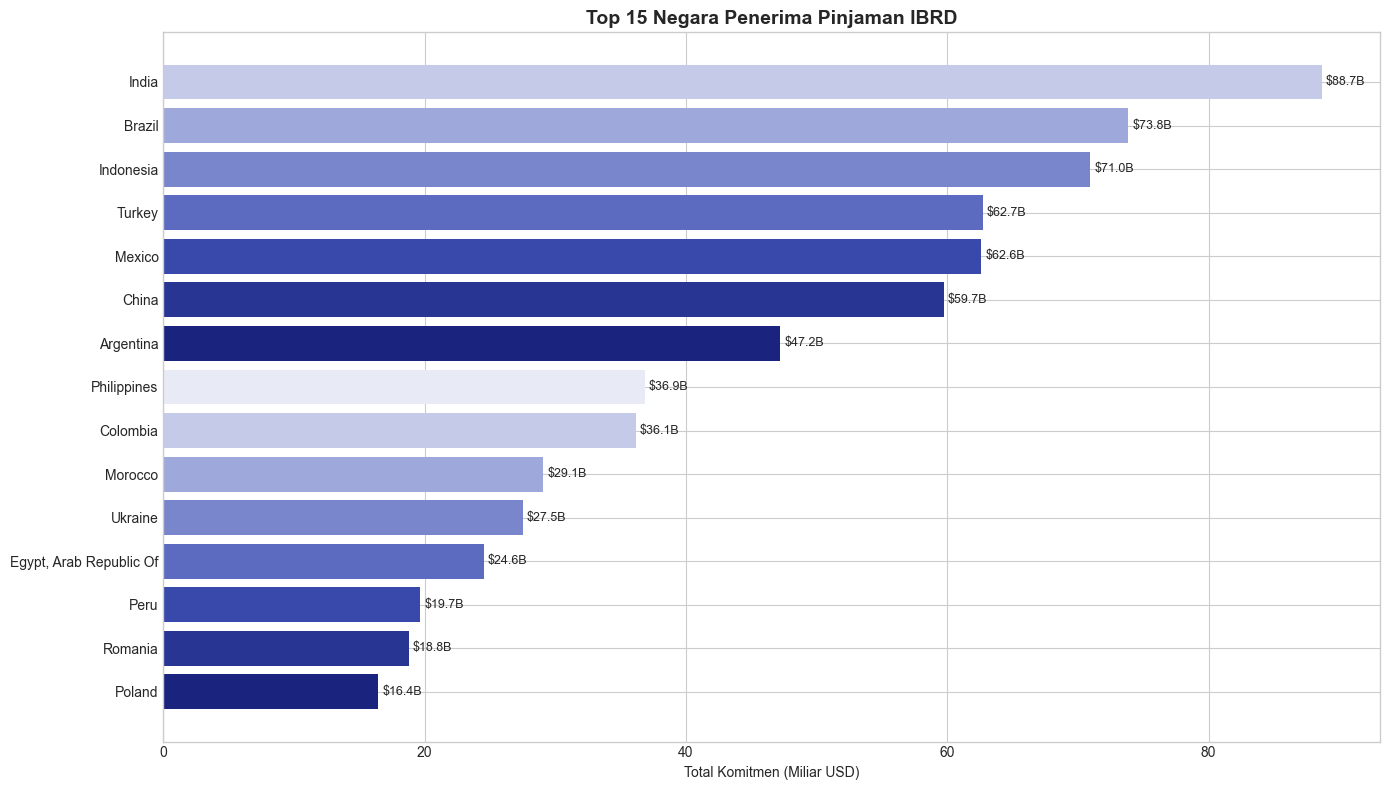


 INSIGHT 2: Top 5 Negara:
   India                         : $88.7B (432 pinjaman, 0 aktif)
   Brazil                        : $73.8B (530 pinjaman, 0 aktif)
   Indonesia                     : $71.0B (588 pinjaman, 0 aktif)
   Turkey                        : $62.7B (362 pinjaman, 0 aktif)
   Mexico                        : $62.6B (383 pinjaman, 0 aktif)


In [ ]:
# ANALISIS 2: TOP 15 NEGARA PENERIMA PINJAMAN
df_country = query_db("""
    SELECT
        dc.country_name,
        dc.region,
        COUNT(*)                                       AS total_loans,
        ROUND(SUM(f.original_principal_amount)/1e9, 2) AS commitment_bn_usd,
        ROUND(SUM(f.disbursed_amount)/1e9, 2)          AS disbursed_bn_usd,
        ROUND(AVG(f.risk_ratio) * 100, 2)              AS avg_risk_pct,
        SUM(CASE WHEN f.loan_status = 'Active' THEN 1 ELSE 0 END) AS active_loans
    FROM fact_loans f
    JOIN dim_country dc ON f.country_id = dc.country_id
    WHERE f.original_principal_amount > 0
    GROUP BY dc.country_name, dc.region
    ORDER BY commitment_bn_usd DESC
    LIMIT 15
""")

display(df_country)

fig, ax = plt.subplots(figsize=(14, 8))
colors  = [COLORS[i % len(COLORS)] for i in range(len(df_country))]
bars    = ax.barh(df_country["country_name"][::-1], df_country["commitment_bn_usd"][::-1], color=colors)
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.3, bar.get_y() + bar.get_height()/2, f"${w:.1f}B", va="center", fontsize=9)
ax.set_xlabel("Total Komitmen (Miliar USD)")
ax.set_title("Top 15 Negara Penerima Pinjaman IBRD", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(DATA_DIR / "analisis_top_countries.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n INSIGHT 2: Top 5 Negara:")
for _, row in df_country.head(5).iterrows():
    print(f"   {row['country_name']:30s}: ${row['commitment_bn_usd']:.1f}B "
          f"({row['total_loans']} pinjaman, {row['active_loans']} aktif)")

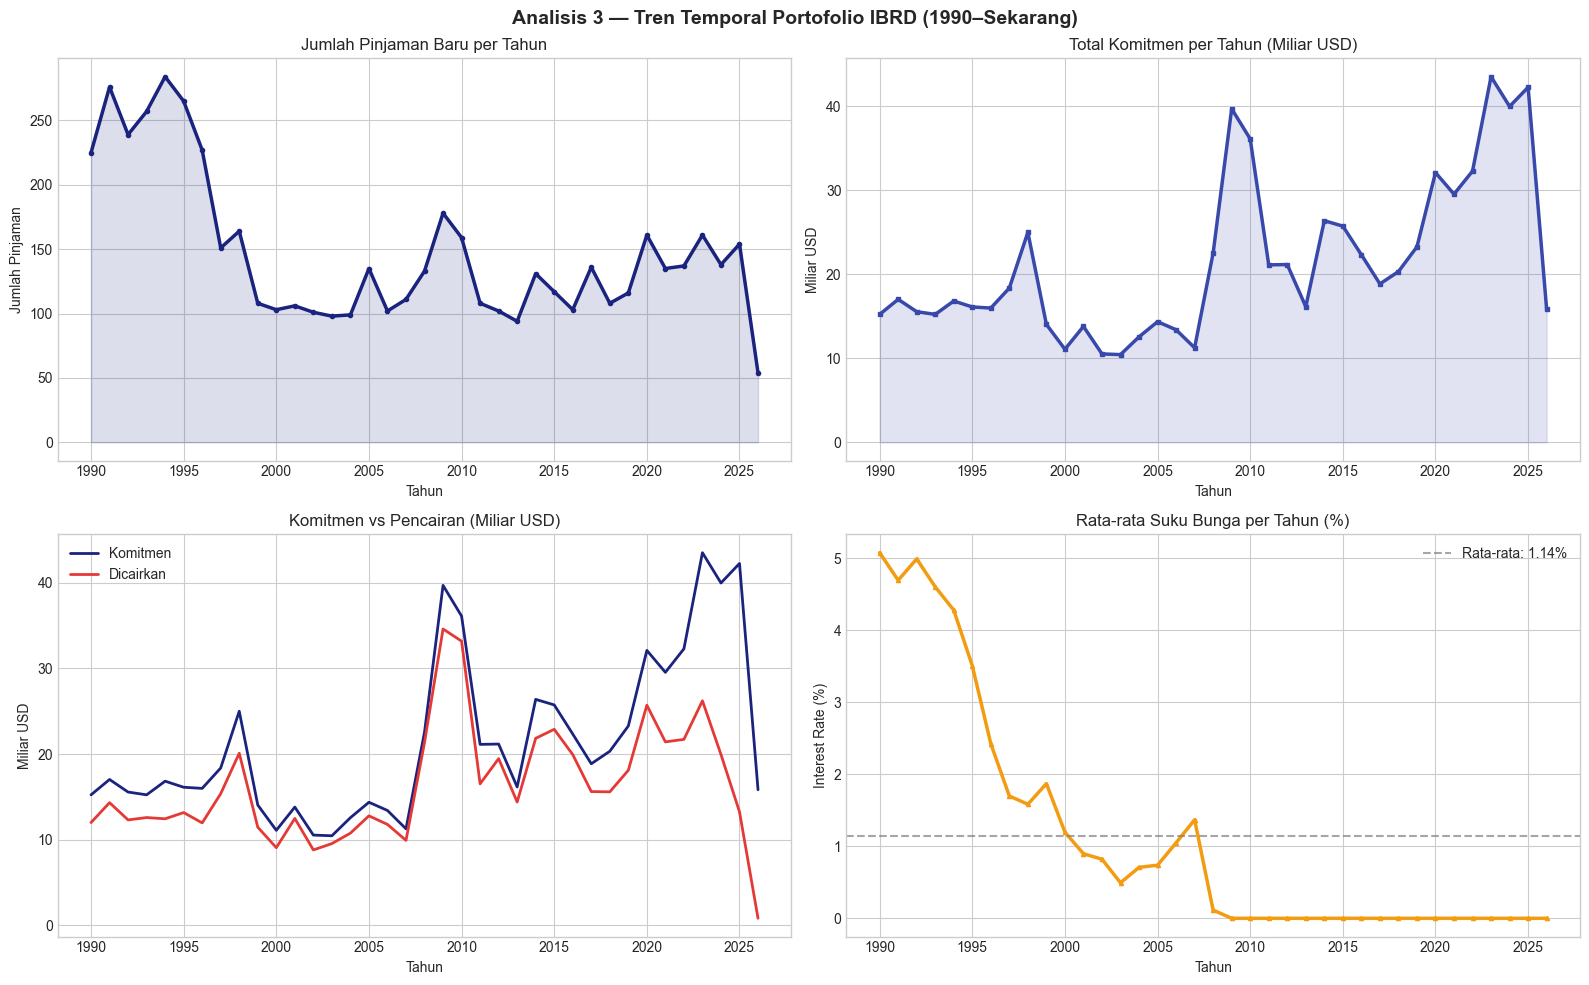


💡 INSIGHT 3: Tahun dengan komitmen tertinggi: 2023 ($43.5B, 161 pinjaman)


In [ ]:
# ANALISIS 3 — TREN TEMPORAL (PER TAHUN)

df_trend = query_db("""
    SELECT
        ti.year,
        ti.quarter,
        ti.year_quarter,
        COUNT(f.loan_id)                               AS new_loans,
        ROUND(SUM(f.original_principal_amount)/1e9, 3) AS commitment_bn,
        ROUND(SUM(f.disbursed_amount)/1e9, 3)          AS disbursed_bn,
        ROUND(AVG(f.interest_rate), 4)                 AS avg_interest
    FROM fact_loans f
    JOIN dim_time ti ON f.approval_time_id = ti.time_id
    WHERE ti.year >= 1990
    GROUP BY ti.year, ti.quarter, ti.year_quarter
    ORDER BY ti.year, ti.quarter
""")

df_annual = df_trend.groupby("year").agg(
    new_loans     = ("new_loans",     "sum"),
    commitment_bn = ("commitment_bn", "sum"),
    disbursed_bn  = ("disbursed_bn",  "sum"),
    avg_interest  = ("avg_interest",  "mean")
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Analisis 3 — Tren Temporal Portofolio IBRD (1990–Sekarang)",
             fontsize=14, fontweight="bold")

ax = axes[0, 0]
ax.plot(df_annual["year"], df_annual["new_loans"], color=COLORS[0], linewidth=2.5, marker="o", markersize=3)
ax.fill_between(df_annual["year"], df_annual["new_loans"], alpha=0.15, color=COLORS[0])
ax.set_title("Jumlah Pinjaman Baru per Tahun"); ax.set_ylabel("Jumlah Pinjaman")

ax = axes[0, 1]
ax.plot(df_annual["year"], df_annual["commitment_bn"], color=COLORS[2], linewidth=2.5, marker="s", markersize=3)
ax.fill_between(df_annual["year"], df_annual["commitment_bn"], alpha=0.15, color=COLORS[2])
ax.set_title("Total Komitmen per Tahun (Miliar USD)"); ax.set_ylabel("Miliar USD")

ax = axes[1, 0]
ax.plot(df_annual["year"], df_annual["commitment_bn"], label="Komitmen",  color=COLORS[0], linewidth=2)
ax.plot(df_annual["year"], df_annual["disbursed_bn"],  label="Dicairkan", color=ACCENT,    linewidth=2)
ax.set_title("Komitmen vs Pencairan (Miliar USD)"); ax.set_ylabel("Miliar USD"); ax.legend()

ax = axes[1, 1]
ax.plot(df_annual["year"], df_annual["avg_interest"], color="#f39c12", linewidth=2.5, marker="^", markersize=3)
ax.axhline(y=df_annual["avg_interest"].mean(), color="gray", linestyle="--", alpha=0.7,
           label=f"Rata-rata: {df_annual['avg_interest'].mean():.2f}%")
ax.set_title("Rata-rata Suku Bunga per Tahun (%)"); ax.set_ylabel("Interest Rate (%)"); ax.legend()

for ax in axes.flatten():
    ax.set_xlabel("Tahun")

plt.tight_layout()
plt.savefig(DATA_DIR / "analisis_temporal.png", dpi=150, bbox_inches="tight")
plt.show()

peak_year = df_annual.loc[df_annual["commitment_bn"].idxmax()]
print(f"\n💡 INSIGHT 3: Tahun dengan komitmen tertinggi: {int(peak_year['year'])} "
      f"(${peak_year['commitment_bn']:.1f}B, {int(peak_year['new_loans'])} pinjaman)")


Distribusi Risiko Portofolio:


,risk_category,total_loans,commitment_bn,outstanding_bn,avg_interest,avg_disbursement_pct
0,Low Risk,7688,569.29,5.19,4.76,79.29
1,Medium Risk,417,84.27,30.28,0.07,62.98
2,High Risk,679,141.09,89.67,0.05,88.93
3,Critical Risk,613,176.12,167.48,0.02,97.86


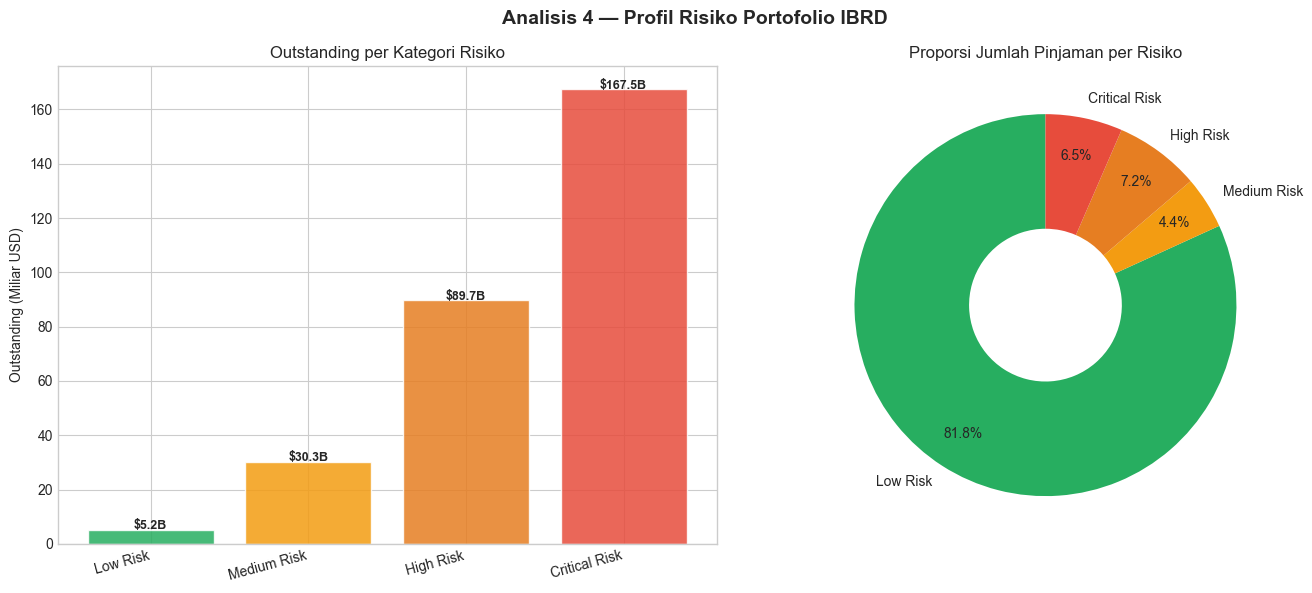


 INSIGHT 4:
   Total portofolio berisiko tinggi: $257.1B outstanding


In [ ]:
# ANALISIS 4: ANALISIS RISIKO PORTOFOLIO

df_risk = query_db("""
    SELECT
        risk_category,
        COUNT(*)                                       AS total_loans,
        ROUND(SUM(original_principal_amount)/1e9, 2)  AS commitment_bn,
        ROUND(SUM(due_amount)/1e9, 2)                 AS outstanding_bn,
        ROUND(AVG(interest_rate), 4)                  AS avg_interest,
        ROUND(AVG(disbursement_ratio) * 100, 2)       AS avg_disbursement_pct
    FROM fact_loans
    WHERE risk_category IS NOT NULL AND risk_category != 'Unknown'
    GROUP BY risk_category
    ORDER BY CASE risk_category
        WHEN 'Low Risk'      THEN 1
        WHEN 'Medium Risk'   THEN 2
        WHEN 'High Risk'     THEN 3
        WHEN 'Critical Risk' THEN 4
        ELSE 5
    END
""")

print("Distribusi Risiko Portofolio:")
display(df_risk)

risk_colors = ["#27ae60", "#f39c12", "#e67e22", "#e74c3c"]
fig, axes   = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Analisis 4 — Profil Risiko Portofolio IBRD", fontsize=14, fontweight="bold")

ax   = axes[0]
x    = range(len(df_risk))
bars = ax.bar(x, df_risk["outstanding_bn"], color=risk_colors[:len(df_risk)], alpha=0.85, edgecolor="white")
ax.set_xticks(list(x)); ax.set_xticklabels(df_risk["risk_category"], rotation=15, ha="right")
ax.set_ylabel("Outstanding (Miliar USD)"); ax.set_title("Outstanding per Kategori Risiko")
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.2, f"${h:.1f}B", ha="center", fontsize=9, fontweight="bold")

ax = axes[1]
ax.pie(df_risk["total_loans"], labels=df_risk["risk_category"],
       autopct="%1.1f%%", colors=risk_colors[:len(df_risk)],
       pctdistance=0.8, startangle=90, wedgeprops={"width": 0.6})
ax.set_title("Proporsi Jumlah Pinjaman per Risiko")

plt.tight_layout()
plt.savefig(DATA_DIR / "analisis_risiko.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n INSIGHT 4:")
high_risk = df_risk[df_risk["risk_category"].isin(["High Risk", "Critical Risk"])]
if len(high_risk) > 0:
    print(f"   Total portofolio berisiko tinggi: ${high_risk['outstanding_bn'].sum():.1f}B outstanding")

Distribusi Status Pinjaman:


,loan_status,total_loans,commitment_bn,avg_age_years
0,Fully Repaid,6612,434.42,6.12
1,Repaying,1169,237.35,5.11
2,Disbursing,505,110.08,5.23
3,Fully Disbursed,287,85.83,3.00
4,Disbursing&Repaying,198,39.15,7.58
5,Approved,80,22.28,5.26
6,Cancelled,223,15.62,4.99
7,Effective,64,13.01,4.85
8,Signed,36,9.41,4.91
9,Repaid,305,5.25,5.71


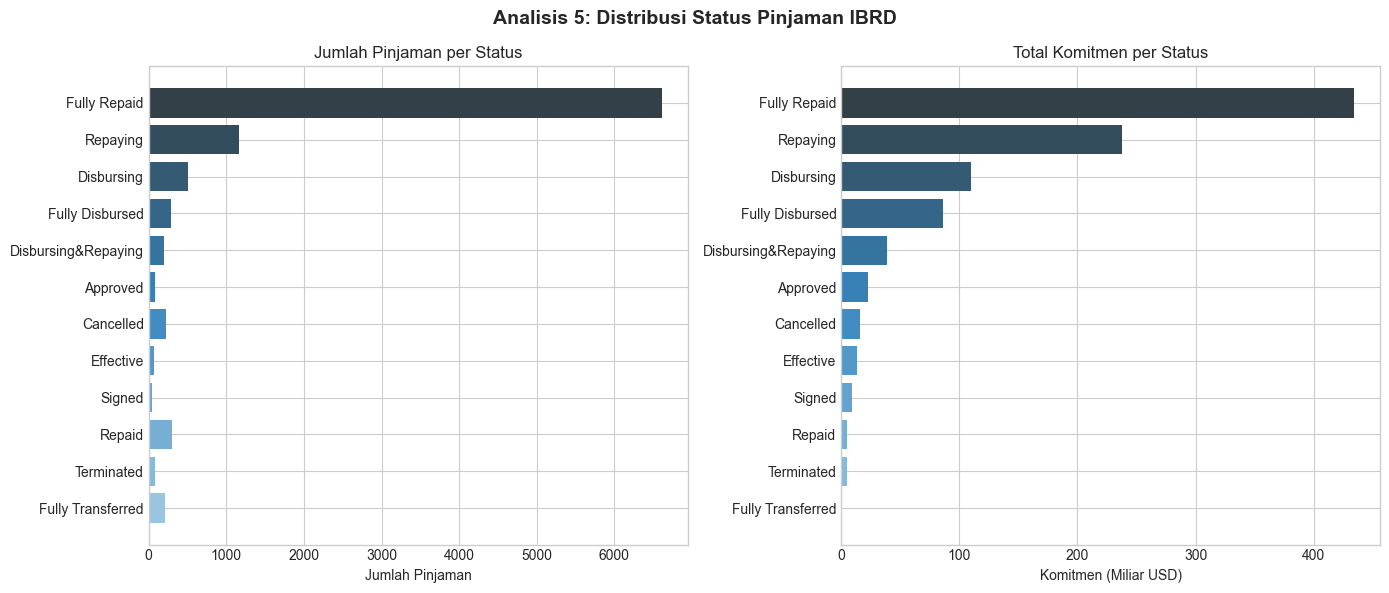

In [ ]:
# ANALISIS 5: DISTRIBUSI STATUS PINJAMAN

df_status = query_db("""
    SELECT
        loan_status,
        COUNT(*)                                        AS total_loans,
        ROUND(SUM(original_principal_amount)/1e9, 2)   AS commitment_bn,
        ROUND(AVG(loan_age_years), 2)                  AS avg_age_years
    FROM fact_loans
    WHERE loan_status IS NOT NULL AND loan_status != 'Unknown'
    GROUP BY loan_status
    ORDER BY commitment_bn DESC
""")

print("Distribusi Status Pinjaman:")
display(df_status)

palette   = sns.color_palette("Blues_d", len(df_status))
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Analisis 5: Distribusi Status Pinjaman IBRD", fontsize=14, fontweight="bold")

ax = axes[0]
ax.barh(df_status["loan_status"][::-1], df_status["total_loans"][::-1], color=palette)
ax.set_xlabel("Jumlah Pinjaman"); ax.set_title("Jumlah Pinjaman per Status")

ax = axes[1]
ax.barh(df_status["loan_status"][::-1], df_status["commitment_bn"][::-1], color=palette)
ax.set_xlabel("Komitmen (Miliar USD)"); ax.set_title("Total Komitmen per Status")

plt.tight_layout()
plt.savefig(DATA_DIR / "analisis_status.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Performance Benchmark PostgreSQL OLAP Extensions <a id='10-benchmark'></a>

Benchmark ini membuktikan manfaat penggunaan **extensions & fitur PostgreSQL** untuk OLAP melalui 3 skenario perbandingan nyata:


Skenario Pengujian

Skenario A: Query Tanpa Index
Pengujian dilakukan pada tabel fact dengan menonaktifkan penggunaan indeks sehingga PostgreSQL menjalankan query menggunakan mekanisme Sequential Scan.

Skenario B: Query Menggunakan Index
Pengujian dilakukan pada tabel fact dengan memanfaatkan indeks B-Tree dan GIN (btree_gin) yang telah dibuat untuk mempercepat proses pencarian dan agregasi data.

Skenario C: Query Menggunakan Materialized View
Pengujian dilakukan menggunakan materialized view yang telah menyimpan hasil agregasi secara pra-komputasi (pre-computed aggregation) sehingga proses analisis OLAP dapat dieksekusi lebih cepat.

**Catatan Metodologi:** Untuk memastikan perbandingan yang adil antara "tanpa index" vs  "dengan index", skenario A menggunakan `SET enable_indexscan = OFF; SET enable_bitmapscan = OFF;`  agar PostgreSQL dipaksa menggunakan **Sequential Scan**.


 Menjalankan benchmark (3x tiap skenario)...

SKENARIO:
  A = Sequential Scan (index DINONAKTIFKAN via SET enable_indexscan = OFF)
  B = Index Scan     (index AKTIF — default PostgreSQL)
  C = Materialized View (pra-komputasi, paling cepat) 


[Regional Aggregation]
  A Sequential Scan :   860.68 ms  (baseline)
  B Index Scan      :   545.78 ms   1.6x lebih cepat dari A
  C Materialized MV :   589.62 ms   1.5x lebih cepat dari A

[Top Countries]
  A Sequential Scan :   884.50 ms  (baseline)
  B Index Scan      :   535.73 ms   1.7x lebih cepat dari A
  C Materialized MV :   422.83 ms   2.1x lebih cepat dari A

 Tabel Hasil Benchmark:


,label,min_ms,avg_ms,max_ms,rows
0,Regional Aggregation — A: Sequential Scan,771.89,860.68,910.52,588
1,Regional Aggregation — B: Index Scan,506.84,545.78,615.80,588
2,Regional Aggregation — C: Materialized View,566.41,589.62,612.84,1724
3,Top Countries — A: Sequential Scan,773.97,884.50,990.45,20
4,Top Countries — B: Index Scan,426.42,535.73,590.68,20
5,Top Countries — C: Materialized View,413.91,422.83,438.68,20


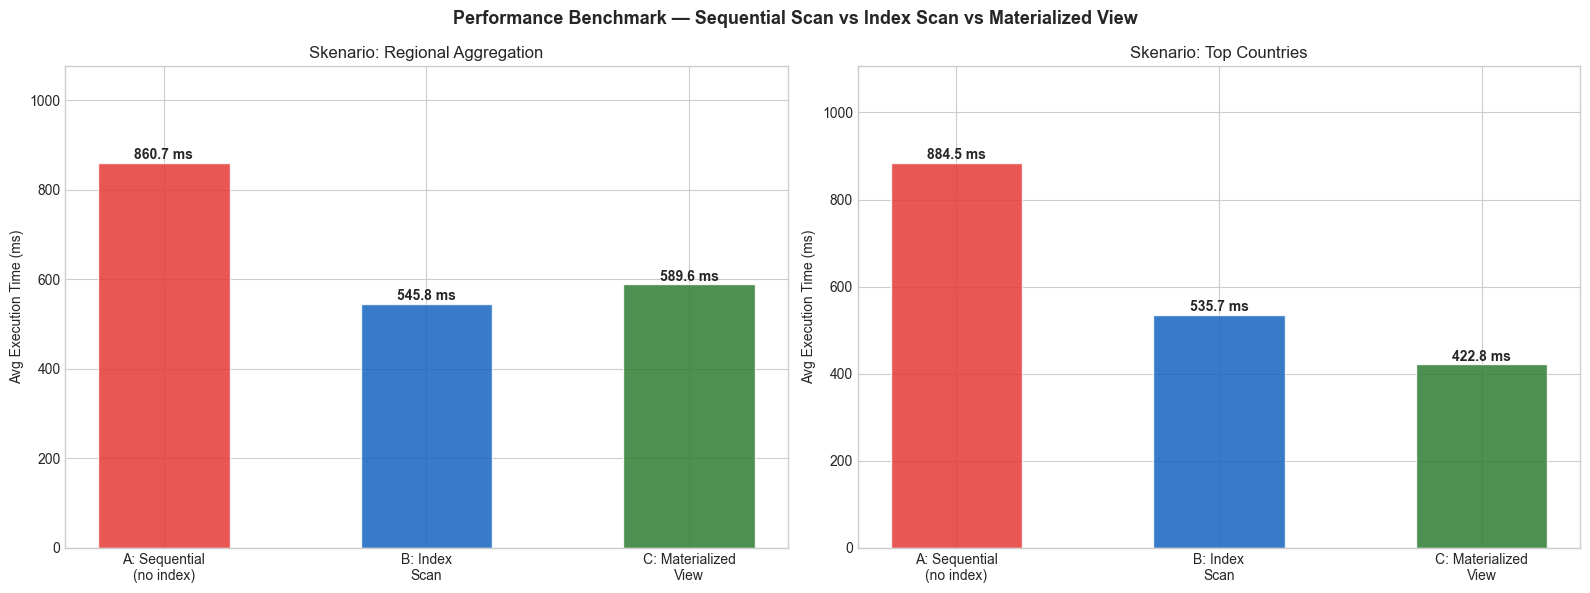


Benchmark selesai! Visualisasi disimpan di data/benchmark_index_comparison.png


In [ ]:
def benchmark_query(engine, query: str, label: str, runs: int = 3,
                    pre_sql: str = None, post_sql: str = None) -> dict:
    """
    Jalankan query N kali dan hitung rata-rata waktu eksekusi.
    pre_sql  : SQL dijalankan SEBELUM query (misal SET enable_indexscan = OFF)
    post_sql : SQL dijalankan SETELAH query (misal RESET ALL)
    """
    times = []
    row_count = 0
    for _ in range(runs):
        start = time.perf_counter()
        with engine.begin() as conn:
            if pre_sql:
                for s in pre_sql.split(';'):
                    s = s.strip()
                    if s:
                        conn.execute(text(s))
            result    = conn.execute(text(query))
            rows      = result.fetchall()
            row_count = len(rows)
            if post_sql:
                for s in post_sql.split(';'):
                    s = s.strip()
                    if s:
                        conn.execute(text(s))
        elapsed = time.perf_counter() - start
        times.append(elapsed)
    return {
        "label" : label,
        "min_ms": round(min(times) * 1000, 2),
        "avg_ms": round(sum(times) / len(times) * 1000, 2),
        "max_ms": round(max(times) * 1000, 2),
        "rows"  : row_count,
    }


# Query yang akan dibandingkan
QUERY_AGG = """
    SELECT dc.region,
           EXTRACT(YEAR FROM f.board_approval_date) AS year,
           COUNT(f.loan_id)                         AS total_loans,
           SUM(f.original_principal_amount)         AS total_commitment
    FROM fact_loans f
    JOIN dim_country dc ON f.country_id = dc.country_id
    WHERE f.original_principal_amount > 0
    GROUP BY dc.region, EXTRACT(YEAR FROM f.board_approval_date)
    ORDER BY year DESC
"""

QUERY_MV = """
    SELECT region, year, total_loans, total_commitment_usd
    FROM mv_loan_by_region_year
    ORDER BY year DESC
"""

QUERY_COUNTRY = """
    SELECT dc.country_name,
           COUNT(f.loan_id)                  AS total_loans,
           SUM(f.original_principal_amount)  AS total_commitment,
           AVG(f.risk_ratio)                 AS avg_risk
    FROM fact_loans f
    JOIN dim_country dc ON f.country_id = dc.country_id
    GROUP BY dc.country_name
    ORDER BY total_commitment DESC
    LIMIT 20
"""

QUERY_COUNTRY_MV = """
    SELECT country_name, total_loans, total_commitment_usd, avg_risk_ratio
    FROM mv_top_countries
    ORDER BY total_commitment_usd DESC
    LIMIT 20
"""

# Konfigurasi pre/post SQL untuk paksa Sequential Scan
NO_INDEX_PRE  = "SET enable_indexscan = OFF; SET enable_bitmapscan = OFF"
RESET_POST    = "RESET ALL"

print(" Menjalankan benchmark (3x tiap skenario)...\n")
print("SKENARIO:")
print("  A = Sequential Scan (index DINONAKTIFKAN via SET enable_indexscan = OFF)")
print("  B = Index Scan     (index AKTIF — default PostgreSQL)")
print("  C = Materialized View (pra-komputasi, paling cepat) \n")

bench_results = []

for base_q, mv_q, label in [
    (QUERY_AGG,     QUERY_MV,        "Regional Aggregation"),
    (QUERY_COUNTRY, QUERY_COUNTRY_MV, "Top Countries"),
]:
    # Skenario A: Sequential Scan (paksa tanpa index)
    r_seq = benchmark_query(engine, base_q, f"{label} — A: Sequential Scan",
                            pre_sql=NO_INDEX_PRE, post_sql=RESET_POST)
    # Skenario B: Index Scan (default)
    r_idx = benchmark_query(engine, base_q, f"{label} — B: Index Scan")
    # Skenario C: Materialized View
    r_mv  = benchmark_query(engine, mv_q,   f"{label} — C: Materialized View")

    bench_results.extend([r_seq, r_idx, r_mv])

    speedup_idx = r_seq["avg_ms"] / r_idx["avg_ms"] if r_idx["avg_ms"] > 0 else 0
    speedup_mv  = r_seq["avg_ms"] / r_mv["avg_ms"]  if r_mv["avg_ms"]  > 0 else 0

    print(f"\n[{label}]")
    print(f"  A Sequential Scan : {r_seq['avg_ms']:8.2f} ms  (baseline)")
    print(f"  B Index Scan      : {r_idx['avg_ms']:8.2f} ms   {speedup_idx:.1f}x lebih cepat dari A")
    print(f"  C Materialized MV : {r_mv['avg_ms']:8.2f} ms   {speedup_mv:.1f}x lebih cepat dari A")

df_bench = pd.DataFrame(bench_results)
print("\n Tabel Hasil Benchmark:")
display(df_bench)

# Visualisasi Benchmark
COLORS_BENCH = ["#e53935", "#1565c0", "#2e7d32"]  # Merah=Seq, Biru=Index, Hijau=MV

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "Performance Benchmark — Sequential Scan vs Index Scan vs Materialized View",
    fontsize=13, fontweight="bold"
)

for ax_i, label in enumerate(["Regional Aggregation", "Top Countries"]):
    ax     = axes[ax_i]
    subset = df_bench[df_bench["label"].str.startswith(label)]
    labels = ["A: Sequential\n(no index)", "B: Index\nScan", "C: Materialized\nView"]
    values = subset["avg_ms"].values
    colors = COLORS_BENCH[:len(values)]
    bars   = ax.bar(labels, values, color=colors, alpha=0.85, edgecolor="white", width=0.5)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f"{h:.1f} ms",
                ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_ylabel("Avg Execution Time (ms)")
    ax.set_title(f"Skenario: {label}")
    ax.set_ylim(0, max(values) * 1.25)

plt.tight_layout()
plt.savefig(DATA_DIR / "benchmark_index_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nBenchmark selesai! Visualisasi disimpan di data/benchmark_index_comparison.png")

In [ ]:
# EXECUTION PLAN: Bukti perbandingan Sequential Scan vs Index Scan
print("EXECUTION PLAN ANALYSIS")

QUERY_BASE = """
    SELECT * FROM fact_loans
    WHERE loan_status = 'Active'
    AND original_principal_amount > 100000000
"""

# Plan A: Sequential Scan (index dinonaktifkan)
with engine.begin() as conn:
    conn.execute(text("SET enable_indexscan = OFF; SET enable_bitmapscan = OFF"))
    result = conn.execute(text(f"EXPLAIN ANALYZE {QUERY_BASE}"))
    plan_seq = "\n".join([row[0] for row in result.fetchall()])
    conn.execute(text("RESET ALL"))

print("\n Plan A: Sequential Scan (index dinonaktifkan): \n ")
print(plan_seq)

# Plan B: Index Scan (default)
with engine.connect() as conn:
    result = conn.execute(text(f"EXPLAIN ANALYZE {QUERY_BASE}"))
    plan_idx = "\n".join([row[0] for row in result.fetchall()])

print("\n Plan B: Index Scan (default, index aktif): \n ")
print(plan_idx)

# Ringkasan
print(" RINGKASAN EKSTENSI PostgreSQL YANG DIGUNAKAN: \n")

with engine.connect() as conn:
    result = conn.execute(text("""
        SELECT extname, extversion,
               CASE extname
                   WHEN 'pg_stat_statements' THEN 'Query profiling & audit performa'
                   WHEN 'btree_gin'          THEN 'GIN multi-column index pada fact_loans'
                   WHEN 'pg_trgm'            THEN 'Trigram full-text search (project_name, borrower)'
                   ELSE 'General'
               END AS kegunaan
        FROM pg_extension
        WHERE extname IN ('pg_stat_statements', 'btree_gin', 'pg_trgm')
        ORDER BY extname
    """))
    ext_rows = result.fetchall()

if ext_rows:
    for row in ext_rows:
        print(f"  ✅ {row[0]:25s} v{row[1]:6s} → {row[2]}")
else:
    print("  Extensions belum terinstall — pastikan konfigurasi Supabase sudah benar")

EXECUTION PLAN ANALYSIS

 Plan A: Sequential Scan (index dinonaktifkan): 
 
Append  (cost=0.00..415.55 rows=6 width=243) (actual time=2.305..2.306 rows=0 loops=1)
  ->  Seq Scan on fact_loans_before_2000 fact_loans_1  (cost=0.00..269.32 rows=1 width=228) (actual time=1.441..1.441 rows=0 loops=1)
        Filter: ((original_principal_amount > '100000000'::numeric) AND ((loan_status)::text = 'Active'::text))
        Rows Removed by Filter: 6488
  ->  Seq Scan on fact_loans_2000_2005 fact_loans_2  (cost=0.00..22.61 rows=1 width=237) (actual time=0.142..0.142 rows=0 loops=1)
        Filter: ((original_principal_amount > '100000000'::numeric) AND ((loan_status)::text = 'Active'::text))
        Rows Removed by Filter: 507
  ->  Seq Scan on fact_loans_2005_2010 fact_loans_3  (cost=0.00..28.88 rows=1 width=244) (actual time=0.164..0.164 rows=0 loops=1)
        Filter: ((original_principal_amount > '100000000'::numeric) AND ((loan_status)::text = 'Active'::text))
        Rows Removed by Filter: 

In [ ]:
# Ringkasan
print(" RINGKASAN EKSTENSI PostgreSQL YANG DIGUNAKAN: \n")

with engine.connect() as conn:
    result = conn.execute(text("""
        SELECT extname, extversion,
               CASE extname
                   WHEN 'pg_stat_statements' THEN 'Query profiling & audit performa'
                   WHEN 'btree_gin'          THEN 'GIN multi-column index pada fact_loans'
                   WHEN 'pg_trgm'            THEN 'Trigram full-text search (project_name, borrower)'
                   ELSE 'General'
               END AS kegunaan
        FROM pg_extension
        WHERE extname IN ('pg_stat_statements', 'btree_gin', 'pg_trgm')
        ORDER BY extname
    """))
    ext_rows = result.fetchall()

if ext_rows:
    for row in ext_rows:
        print(f"  ✅ {row[0]:25s} v{row[1]:6s} → {row[2]}")
else:
    print("  Extensions belum terinstall — pastikan konfigurasi Supabase sudah benar")

 RINGKASAN EKSTENSI PostgreSQL YANG DIGUNAKAN: 

  ✅ btree_gin                 v1.3    → GIN multi-column index pada fact_loans
  ✅ pg_stat_statements        v1.11   → Query profiling & audit performa
  ✅ pg_trgm                   v1.6    → Trigram full-text search (project_name, borrower)


In [ ]:
# Tampilkan pg_stat_statements top queries
print("\nTop 5 Query Paling Lambat (pg_stat_statements):")
try:
    with engine.connect() as conn:
        result = conn.execute(text("""
            SELECT
                LEFT(query, 80)         AS query_preview,
                calls,
                ROUND(mean_exec_time::numeric, 2) AS avg_ms,
                ROUND(total_exec_time::numeric, 2) AS total_ms
            FROM pg_stat_statements
            WHERE query NOT LIKE '%pg_stat%'
            ORDER BY mean_exec_time DESC
            LIMIT 5
        """))
        df_stats = pd.DataFrame(result.fetchall(), columns=["query_preview", "calls", "avg_ms", "total_ms"])
        display(df_stats)
except Exception as e:
    print(f"   pg_stat_statements: {e}")


Top 5 Query Paling Lambat (pg_stat_statements):


,query_preview,calls,avg_ms,total_ms
0,-- postgres-migrations disable-transaction\n--...,1,791.84,791.84
1,SELECT name FROM pg_timezone_names,126,447.11,56335.27
2,SELECT\n ROUND(SUM(original_principal_a...,1,311.75,311.75
3,"SELECT\n e.name,\n n.nspname AS schema,\n e...",11,291.19,3203.08
4,"INSERT INTO fact_loans (loan_number, project_i...",1,273.51,273.51
